In [1]:
# RUN THIS CELL FIRST. Every later cell relies on these helpers.
import numpy as np
import pandas as pd
import re, json, time, textwrap, math, random
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

np.random.seed(0)

random.seed(0)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 11,
})

# A small, consistent palette reused across every diagram and chart.
PAL = {
    "blue": "#2563eb", "lblue": "#dbeafe",
    "green": "#059669", "lgreen": "#d1fae5",
    "amber": "#d97706", "lamber": "#fef3c7",
    "red": "#dc2626", "lred": "#fee2e2",
    "purple": "#7c3aed", "lpurple": "#ede9fe",
    "slate": "#475569", "ink": "#0f172a",
}

def blank_canvas(figw=10, figh=5.5, xlim=10, ylim=6, title=None):
    # A clean axes with no ticks/grid for drawing flowcharts and diagrams.
    fig, ax = plt.subplots(figsize=(figw, figh))
    ax.set_xlim(0, xlim); ax.set_ylim(0, ylim)
    ax.axis("off"); ax.grid(False)
    if title:
        ax.set_title(title)
    return fig, ax

def add_box(ax, x, y, w, h, label, fc=PAL["lblue"], ec=PAL["blue"], tc=PAL["ink"], fs=10):
    # Draw a rounded, labelled box.
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec=ec, lw=1.6))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=fs, color=tc)

def add_arrow(ax, x1, y1, x2, y2, text="", color=PAL["slate"], style="-|>"):
    # Draw an arrow between two points, with an optional mid-label.
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=1.7))
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2, text, ha="center", va="center",
                fontsize=8, color=color, backgroundcolor="white")

# ---- Token + cost helpers --------------------------------------------------
def approx_tokens(text):
    # Rough English heuristic: ~4 characters per token. Real tokenizers (BPE)
    # differ, but this is plenty for cost/budget intuition in class.
    if not text:
        return 0
    return max(1, round(len(text) / 4))

def estimate_cost(input_tokens, output_tokens, price_in_per_m, price_out_per_m):
    # Prices are ILLUSTRATIVE, given in USD per 1,000,000 tokens. Real prices change.
    return (input_tokens / 1e6) * price_in_per_m + (output_tokens / 1e6) * price_out_per_m

# ---- A mock LLM so the whole notebook runs WITHOUT an API key --------------
# Not a real model: it returns deterministic, templated text so the *shape* of
# LLM code (messages in -> assistant text + token usage) matches production.
# See the API reference cells to swap in a real client.
def chat(messages, temperature=0.7, max_tokens=256, model="mock-llm", responder=None):
    last_user = ""
    for m in messages:
        if m.get("role") == "user":
            last_user = m.get("content", "")
    if responder is not None:
        text = responder(messages)
    else:
        text = "[mock-llm] received " + str(len(messages)) + " message(s); last user: " + last_user[:80]
    prompt_text = " ".join(m.get("content", "") for m in messages)
    pt, ct = approx_tokens(prompt_text), approx_tokens(text)
    return {
        "model": model,
        "choices": [{"message": {"role": "assistant", "content": text}}],
        "usage": {"prompt_tokens": pt, "completion_tokens": ct, "total_tokens": pt + ct},
    }

# ---- Embeddings + retrieval ------------------------------------------------
# Uses REAL sentence-transformers embeddings if the library + model are present;
# otherwise falls back to TF-IDF so retrieval still works fully offline.
from sklearn.feature_extraction.text import TfidfVectorizer

_ST_MODEL = None


def _get_st_model():
    global _ST_MODEL
    if _ST_MODEL is None:
        from sentence_transformers import SentenceTransformer
        _ST_MODEL = SentenceTransformer("all-MiniLM-L6-v2")
    return _ST_MODEL

def _l2norm(X):
    X = np.asarray(X, dtype=float)
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1.0
    return X / n

def embed_texts(texts, prefer_neural=True):
    # Embed a fixed SET of texts together (great for similarity/clustering/2-D plots).
    texts = list(texts)
    if prefer_neural:
        try:
            m = _get_st_model()
            return _l2norm(m.encode(texts)), "sentence-transformers (all-MiniLM-L6-v2)"
        except Exception:
            pass
    X = TfidfVectorizer().fit_transform(texts).toarray()
    return _l2norm(X), "TF-IDF fallback (sklearn)"

def cosine(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

class SemanticIndex:
    # Minimal vector index: embed documents, retrieve by cosine similarity.
    # Same idea as FAISS / Chroma / Pinecone, in a few lines of numpy.
    def __init__(self, docs, prefer_neural=True):
        self.docs = list(docs); self._model = None; self._vec = None
        if prefer_neural:
            try:
                self._model = _get_st_model()
                self.backend = "sentence-transformers (all-MiniLM-L6-v2)"
                self.M = _l2norm(self._model.encode(self.docs)); return
            except Exception:
                pass
        self.backend = "TF-IDF fallback (sklearn)"
        self._vec = TfidfVectorizer().fit(self.docs)
        self.M = _l2norm(self._vec.transform(self.docs).toarray())

    def _embed_query(self, q):
        if self._model is not None:
            return _l2norm(self._model.encode([q]))[0]
        return _l2norm(self._vec.transform([q]).toarray())[0]

    def search(self, query, k=3):
        qv = self._embed_query(query)
        sims = self.M @ qv
        order = np.argsort(-sims)[:k]
        return [{"rank": r + 1, "doc_id": int(i), "score": float(sims[i]), "text": self.docs[i]}
                for r, i in enumerate(order)]

print("Setup complete.")
print("Embedding backend is chosen at first use: neural if sentence-transformers is")
print("installed and a model is reachable, otherwise an automatic TF-IDF fallback.")


Setup complete.
Embedding backend is chosen at first use: neural if sentence-transformers is
installed and a model is reachable, otherwise an automatic TF-IDF fallback.


---
#  Large Language Models & LLM Systems
## Building Real Applications  AI Bootcamp

In the **previous session** we looked *inside* language models: tokenization mechanics, building embeddings from scratch, attention, and how models such as **BERT** and **GPT** are pretrained. This session is deliberately different. We step *outside* the model and learn to **build applications with LLMs**.


**Large Language Model (LLM):** a neural network trained on enormous amounts of text to predict the next *token*. In practice we treat it as a powerful, general-purpose **text-in / text-out engine** that we *steer* with prompts, *ground* with retrieval, *extend* with tools, and *wrap* in production infrastructure.

The model itself is largely a **capable black box** here. The interesting engineering is the **system around it**: how you call it, what context you feed it, how you control its output, how you make it reliable, cheap, fast, and safe.

### What you will be able to do by the end
- Use **LLM APIs** correctly (message roles, streaming, retries, structured outputs, tool calling).
- Reason about **tokens, context windows, latency, and cost** — and budget prompts accordingly.
- Control generation with **temperature, top-p, top-k, and stop sequences**.
- Write better prompts and apply reasoning patterns (**Chain of Thought**, **ReAct**).
- Build a **Retrieval-Augmented Generation (RAG)** pipeline and know when it beats fine-tuning.
- Explain **fine-tuning, LoRA, QLoRA, and quantization** and their memory/compute tradeoffs.
- Design **agents** that plan, act, observe, and use tools — and know when they are overkill.
- Choose between **frameworks** (LangChain, LangGraph, CrewAI, LlamaIndex, and others).
- **Evaluate, debug, and secure** LLM systems and ship them with sane production practices.

### How this session differs from the NLP session

| Previous session (NLP foundations) | This session (LLM systems) |
|---|---|
| How models work *internally* | How to *use* models to build things |
| Tokenization mechanics, BPE internals | Tokens only as a **cost/limit budget** |
| Embeddings *from scratch*, attention math | Embeddings as a **retrieval primitive** |
| Pretraining BERT / GPT | **Prompting, RAG, light fine-tuning, agents** |
| Linguistic / parsing theory | **APIs, evaluation, safety, production** |
| Model-centric | **System-centric** |


## 1. Roadmap of the session

We move from *using* a model, to *grounding* and *adapting* it, to *operating* it in production. Each section builds on the previous one.

**Phase A  Use the model**
1. LLM fundamentals (tokens, context windows, latency, model choice)
2. Working with APIs (messages, streaming, retries, structured outputs, tools)
3. Tokens, context windows & pricing
4. Prompt engineering
5. Sampling & generation controls


6.**Phase B  Reason**  Reasoning techniques (CoT, self-consistency, ReAct, plan-and-execute)

7.**Phase C  Retrieve & ground**  Embeddings
8. **Phase C  Retrieve & ground** Vector databases
9. **Retrieval-Augmented Generation (RAG)** — the big one

**Phase D  Adapt the model**
10. Fine-tuning (and when *not* to)
11. LoRA & QLoRA
12. Quantization

**Phase E  Operate**
13. Agents
14. Agent reasoning patterns & architectures
15. Frameworks
16. Memory
17. Evaluation
18. Safety & security
19. Production concerns

**Phase F  Put it together**
20. End-to-end mini project · Recap · Exercises · Challenge

Run the cell below for a visual map.


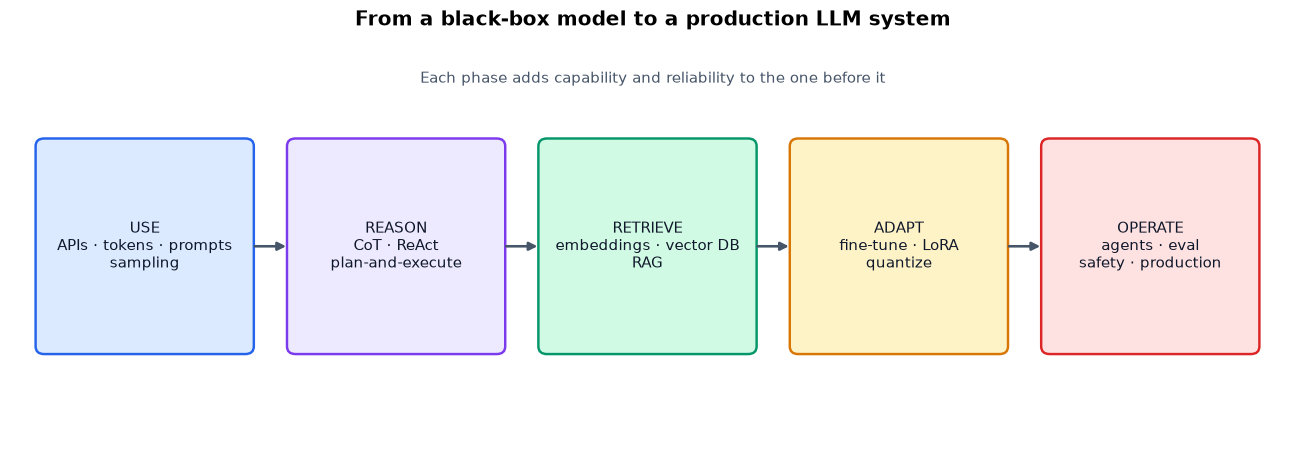

In [2]:

# A visual roadmap: the journey from "use" -> "reason" -> "retrieve" -> "adapt" -> "operate".
fig, ax = blank_canvas(figw=12, figh=4.4, xlim=12, ylim=4.4, title="From a black-box model to a production LLM system")

stages = [
    ("USE\nAPIs · tokens · prompts\nsampling", PAL["lblue"], PAL["blue"]),
    ("REASON\nCoT · ReAct\nplan-and-execute", PAL["lpurple"], PAL["purple"]),
    ("RETRIEVE\nembeddings · vector DB\nRAG", PAL["lgreen"], PAL["green"]),
    ("ADAPT\nfine-tune · LoRA\nquantize", PAL["lamber"], PAL["amber"]),
    ("OPERATE\nagents · eval\nsafety · production", PAL["lred"], PAL["red"]),
]
w, h, gap, y = 2.0, 2.2, 0.35, 1.1
x = 0.25
centers = []
for label, fc, ec in stages:
    add_box(ax, x, y, w, h, label, fc=fc, ec=ec, fs=9.5)
    centers.append(x + w/2)
    x += w + gap
for i in range(len(stages) - 1):
    add_arrow(ax, centers[i] + w/2, y + h/2, centers[i+1] - w/2, y + h/2)
ax.text(6.0, 3.9, "Each phase adds capability and reliability to the one before it",
        ha="center", fontsize=10, color=PAL["slate"])
plt.tight_layout(); plt.show()


## 2. LLM fundamentals (the practical version)

Before building, four practical ideas. We keep the math light — the goal is *operating intuition*.

### 2.1 What an LLM is  and why **decoder-only** models dominate generation
An LLM reads a sequence of tokens and predicts a probability distribution over the **next** token, repeatedly, one token at a time. That single trick — *next-token prediction* — is enough to summarize, translate, write code, answer questions, and follow instructions, once the model is large enough and trained on enough text.

There are three classic Transformer shapes:

| Architecture | Reads | Typical use |
|---|---|---|
| **Encoder-only** (e.g. BERT) | whole input at once, bidirectional | classification, embeddings, understanding |
| **Encoder–decoder** (e.g. T5) | input → output | translation, structured transduction |
| **Decoder-only** (e.g. GPT-style) | left-to-right, predicts next token | **open-ended generation** |

For *generation*, **decoder-only** wins: generating text *is* repeated next-token prediction, so the architecture matches the task, scales cleanly, and lets us stream tokens out as they are produced. Almost every modern chat/instruction model you will call is decoder-only.

### 2.2 Tokens  the unit of everything
Models do not see words or characters; they see **tokens** (sub-word pieces). A rough English rule of thumb:

- **~4 characters ≈ 1 token**, and **~0.75 words ≈ 1 token** (so 1,000 tokens ≈ 750 words).
- Rare words, code, and other languages tokenize into **more** tokens per word.

Tokens matter because **you are billed per token** and **limits are measured in tokens**.

### 2.3 Context window  the model's working memory
The **context window** is the maximum number of tokens the model can consider at once. Crucially it must hold **everything**: the system instructions, the conversation history, the retrieved documents, your current input **and** the space reserved for the output. If the total exceeds the window, something must be **truncated** or **summarized**.

### 2.4 Latency & model choice  why bigger is not always better
Two latency numbers matter: **time-to-first-token (TTFT)** and **tokens-per-second** afterwards. Bigger models are usually *smarter* but *slower* and *pricier*. Real systems mix models: a small fast model for easy/high-volume calls, a large model for hard cases (we will build this **routing** idea in the production section).


In [40]:

# Token intuition: the SAME sentence can cost very different numbers of tokens.
samples = [
    "Hello world.",
    "The cat sat on the mat.",
    "Antidisestablishmentarianism is a long English word.",
    "def f(x): return x**2 + 3*x - 7   # code tends to be token-dense",
    "Tokenization differs across languages and scripts.",
]
rows = []
for s in samples:
    rows.append({
        "text": (s[:42] + "...") if len(s) > 45 else s,
        "chars": len(s),
        "words": len(s.split()),
        "~tokens (chars/4)": approx_tokens(s),
    })
df_tok = pd.DataFrame(rows)
print("Rule of thumb: ~4 chars/token, ~0.75 words/token (so 1k tokens ~ 750 words).\n")
print(df_tok.to_string(index=False))
print("\nNote: this is an APPROXIMATION. A real BPE tokenizer would give exact counts and")
print("would split 'Antidisestablishmentarianism' and code symbols into several tokens each.")


Rule of thumb: ~4 chars/token, ~0.75 words/token (so 1k tokens ~ 750 words).

                                         text  chars  words  ~tokens (chars/4)
                                 Hello world.     12      2                  3
                      The cat sat on the mat.     23      6                  6
Antidisestablishmentarianism is a long Eng...     52      6                 13
def f(x): return x**2 + 3*x - 7   # code t...     64     14                 16
Tokenization differs across languages and ...     50      6                 12

Note: this is an APPROXIMATION. A real BPE tokenizer would give exact counts and
would split 'Antidisestablishmentarianism' and code symbols into several tokens each.


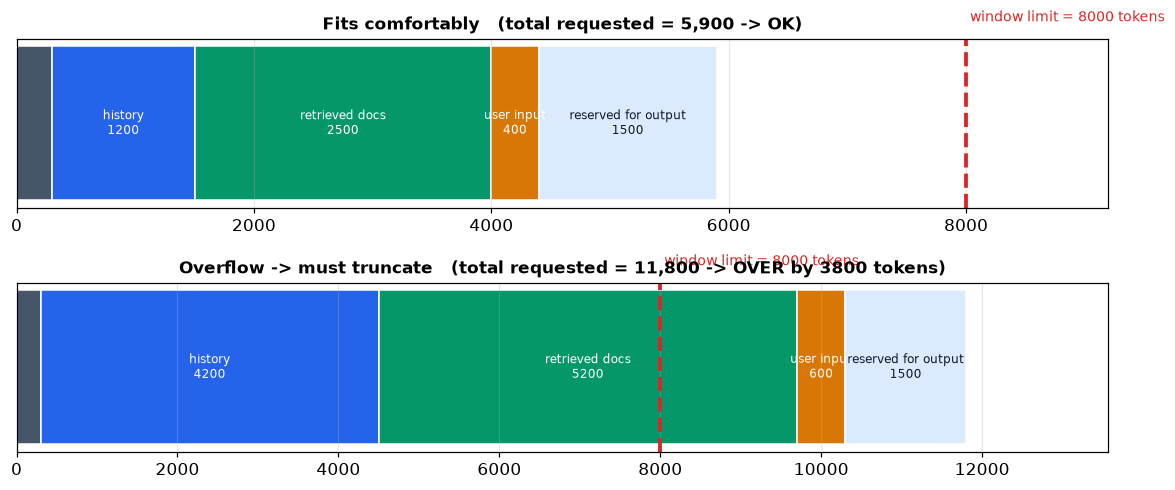

In [41]:

# Visualizing the context window as a fixed budget that must hold EVERYTHING.
fig, axes = plt.subplots(2, 1, figsize=(11, 4.6))
window = 8000  # tokens (illustrative)

scenarios = [
    ("Fits comfortably", {"system": 300, "history": 1200, "retrieved docs": 2500, "user input": 400, "reserved for output": 1500}),
    ("Overflow -> must truncate", {"system": 300, "history": 4200, "retrieved docs": 5200, "user input": 600, "reserved for output": 1500}),
]
seg_colors = [PAL["slate"], PAL["blue"], PAL["green"], PAL["amber"], PAL["lblue"]]

for ax, (title, parts) in zip(axes, scenarios):
    left = 0
    for (name, val), c in zip(parts.items(), seg_colors):
        ax.barh(0, val, left=left, color=c, edgecolor="white")
        if val > 350:
            ax.text(left + val/2, 0, f"{name}\n{val}", ha="center", va="center",
                    fontsize=8, color="white" if c != PAL["lblue"] else PAL["ink"])
        left += val
    ax.axvline(window, color=PAL["red"], lw=2.5, ls="--")
    ax.text(window, 0.55, f" window limit = {window} tokens", color=PAL["red"], fontsize=9, va="center")
    used = sum(parts.values())
    state = "OK" if used <= window else f"OVER by {used - window} tokens"
    ax.set_title(f"{title}   (total requested = {used:,} -> {state})", fontsize=11)
    ax.set_yticks([]); ax.set_xlim(0, max(window, used) * 1.15); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Working with LLM APIs

You will almost always use an LLM through a **chat completion API**. Master this and 80% of LLM engineering is mechanical.

### 3.1 The message list & roles
A request is a list of messages, each with a **role**:

- **`system`** — standing instructions / persona / rules (set once, applies throughout).
- **`user`** — what the human says.
- **`assistant`** — what the model previously said (you replay history so the model has context).

The API is **stateless**: the model has no memory between calls, so *you* must send the relevant history every time.

### 3.2 What you control around the call
| Concern | What it means | Practical handling |
|---|---|---|
| **Streaming** | tokens arrive incrementally | improves perceived latency; show text as it lands |
| **Rate limits** | requests/tokens per minute caps | respect headers; queue; spread load |
| **Retries** | transient `429`/`5xx` errors | **exponential backoff + jitter**, capped attempts |
| **Errors** | timeouts, bad input, content filters | catch by type; never crash the whole app |
| **Structured output** | force machine-readable replies | **JSON mode** or **schema/grammar** constraints |
| **Tool / function calling** | model asks you to run a function | you execute it and feed the result back |

### 3.3 Reference: a real call (provider-agnostic)
The mock `chat()` in this notebook mirrors the shape below. To go live, install your provider's SDK and replace `chat()`.

```python
# OpenAI-style (others are nearly identical in shape)
from openai import OpenAI
client = OpenAI()  # reads OPENAI_API_KEY from the environment

resp = client.chat.completions.create(
    model="<your-model-id>",
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user",   "content": "Explain RAG in one sentence."},
    ],
    temperature=0.3,
    max_tokens=200,
)
print(resp.choices[0].message.content)
print(resp.usage)  # prompt_tokens, completion_tokens, total_tokens

# Streaming: iterate partial chunks for snappy UIs
# for chunk in client.chat.completions.create(..., stream=True):
#     print(chunk.choices[0].delta.content or "", end="")
```

> Anthropic, Google, Mistral, and others expose the **same conceptual shape** (messages + roles + sampling params + usage). Learn one and you can read them all.


In [42]:

# A clean request using our mock chat(): same message/role shape as production.
messages = [
    {"role": "system", "content": "You are a concise teaching assistant. Answer in one sentence."},
    {"role": "user",   "content": "What is a context window?"},
]
resp = chat(messages, temperature=0.3, max_tokens=60)

print("Assistant:", resp["choices"][0]["message"]["content"])
print("\nUsage:", resp["usage"])
print("\n(The mock echoes structure; a real model would answer the question. The point is")
print(" that messages-in -> assistant-text + token-usage is identical to a live API.)")


Assistant: [mock-llm] received 2 message(s); last user: What is a context window?

Usage: {'prompt_tokens': 22, 'completion_tokens': 18, 'total_tokens': 40}

(The mock echoes structure; a real model would answer the question. The point is
 that messages-in -> assistant-text + token-usage is identical to a live API.)


In [43]:

# Structured output: ask for JSON, then PARSE and VALIDATE it (never trust raw text).
# We simulate a JSON-mode response with a responder; in production you'd set the
# provider's JSON/schema mode so the model is constrained to valid JSON.
def json_responder(messages):
    # Pretend the model returned a JSON object (sometimes wrapped in code fences).
    return "```json\n{\"sentiment\": \"positive\", \"score\": 0.92, \"topics\": [\"delivery\", \"price\"]}\n```"

raw = chat([{"role": "user", "content": "Classify this review as JSON."}],
           responder=json_responder)["choices"][0]["message"]["content"]

def parse_json_safely(text):
    # Strip common ```json fences, then parse. Return (ok, value_or_error).
    cleaned = re.sub(r"^```(json)?|```$", "", text.strip(), flags=re.MULTILINE).strip()
    try:
        return True, json.loads(cleaned)
    except Exception as e:
        return False, str(e)

ok, value = parse_json_safely(raw)
print("Raw model text:\n", raw, "\n")
print("Parsed OK:", ok)
print("Value:", value)

# Lightweight schema validation: required keys + types.
schema = {"sentiment": str, "score": float, "topics": list}
def validate(obj, schema):
    problems = []
    for key, typ in schema.items():
        if key not in obj:
            problems.append(f"missing key: {key}")
        elif not isinstance(obj[key], typ):
            problems.append(f"wrong type for {key}: expected {typ.__name__}")
    return problems

print("Validation problems:", validate(value, schema) or "none -> safe to use downstream")


Raw model text:
 ```json
{"sentiment": "positive", "score": 0.92, "topics": ["delivery", "price"]}
``` 

Parsed OK: True
Value: {'sentiment': 'positive', 'score': 0.92, 'topics': ['delivery', 'price']}
Validation problems: none -> safe to use downstream


In [44]:

# Tool / function calling (the core idea): the model asks for a tool; YOU run it.
# Here a responder decides a calculator is needed and emits a tool request.
def tool_responder(messages):
    user = messages[-1]["content"]
    if any(ch.isdigit() for ch in user):
        return json.dumps({"tool": "calculator", "args": {"expression": "(120*3) + 45"}})
    return json.dumps({"final": "No tool needed."})

# 1) Model turn: it requests a tool.
req = json.loads(chat([{"role": "user", "content": "What is 120*3 + 45?"}],
                      responder=tool_responder)["choices"][0]["message"]["content"])
print("Model requested:", req)

# 2) Your app executes the tool (safely!).
def calculator(expression):
    # In real systems, NEVER eval untrusted input. Use a safe parser / allowlist.
    allowed = set("0123456789+-*/(). ")
    if not set(expression) <= allowed:
        raise ValueError("unsafe expression")
    return eval(expression)  # safe here only because we validated the characters

result = calculator(req["args"]["expression"])
print("Tool result:", result)

# 3) Feed the result back so the model can finish (mocked).
final = chat([
    {"role": "user", "content": "What is 120*3 + 45?"},
    {"role": "assistant", "content": f"(used calculator) = {result}"},
])
print("Final answer would be grounded on:", result)


Model requested: {'tool': 'calculator', 'args': {'expression': '(120*3) + 45'}}
Tool result: 405
Final answer would be grounded on: 405


In [45]:

# Robust retries with exponential backoff + jitter (runnable, fast simulation).
def flaky_call(state={"n": 0}):
    # Fails twice, then succeeds -- to demonstrate the retry policy.
    state["n"] += 1
    if state["n"] < 3:
        raise TimeoutError(f"transient error (attempt {state['n']})")
    return "success"

def with_retries(fn, max_attempts=5, base=0.5):
    for attempt in range(1, max_attempts + 1):
        try:
            return fn()
        except (TimeoutError, ConnectionError) as e:
            wait = base * (2 ** (attempt - 1)) + random.uniform(0, 0.2)  # backoff + jitter
            print(f"attempt {attempt} failed: {e}  -> backing off ~{wait:.2f}s")
            time.sleep(0)  # set to time.sleep(wait) in real code; 0 here to keep the demo fast
    raise RuntimeError("exhausted retries")

print("Result:", with_retries(flaky_call))


attempt 1 failed: transient error (attempt 1)  -> backing off ~0.66s
attempt 2 failed: transient error (attempt 2)  -> backing off ~1.11s
Result: success


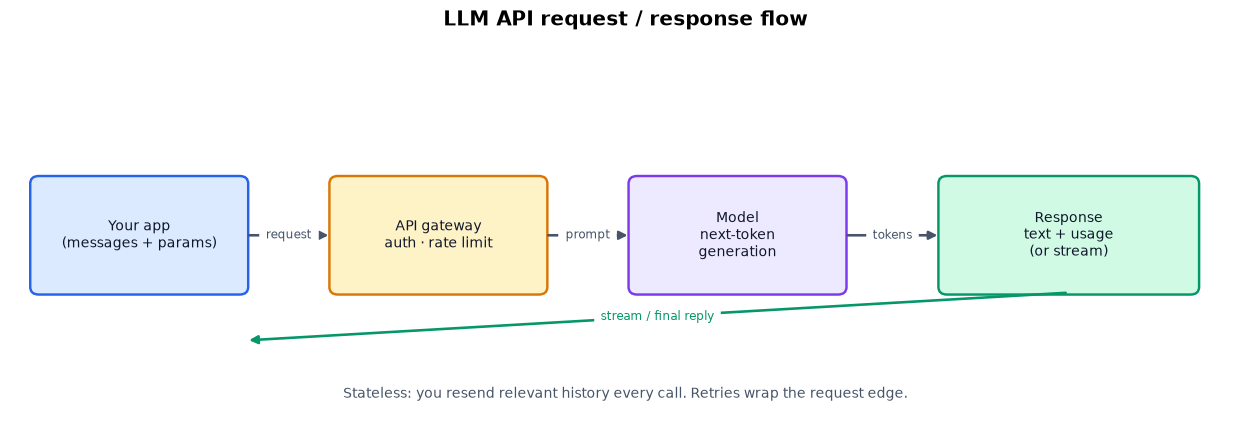

In [46]:

# Request/response flow diagram.
fig, ax = blank_canvas(figw=11.5, figh=4.2, xlim=11.5, ylim=4.2,
                       title="LLM API request / response flow")
add_box(ax, 0.2, 1.5, 2.0, 1.2, "Your app\n(messages + params)", fc=PAL["lblue"], ec=PAL["blue"], fs=9)
add_box(ax, 3.0, 1.5, 2.0, 1.2, "API gateway\nauth · rate limit", fc=PAL["lamber"], ec=PAL["amber"], fs=9)
add_box(ax, 5.8, 1.5, 2.0, 1.2, "Model\nnext-token\ngeneration", fc=PAL["lpurple"], ec=PAL["purple"], fs=9)
add_box(ax, 8.7, 1.5, 2.4, 1.2, "Response\ntext + usage\n(or stream)", fc=PAL["lgreen"], ec=PAL["green"], fs=9)
add_arrow(ax, 2.2, 2.1, 3.0, 2.1, "request")
add_arrow(ax, 5.0, 2.1, 5.8, 2.1, "prompt")
add_arrow(ax, 7.8, 2.1, 8.7, 2.1, "tokens")
add_arrow(ax, 9.9, 1.5, 2.2, 1.0, "stream / final reply", color=PAL["green"])
ax.text(5.75, 0.4, "Stateless: you resend relevant history every call. Retries wrap the request edge.",
        ha="center", fontsize=9, color=PAL["slate"])
plt.tight_layout(); plt.show()


## 4. Tokens, context windows & pricing

This section is about **money and limits**. Getting it wrong is the most common way LLM projects blow their budget or fail in production.

### 4.1 What you pay for
- **Input (prompt) tokens** — everything you send: system prompt, history, retrieved docs, the user message.
- **Output (completion) tokens** — what the model generates. **Output is usually priced higher than input.**
- **Cached tokens** — many providers let you reuse a large, unchanging prefix (e.g. a long system prompt) at a **steep discount**. Huge savings for repeated calls.

### 4.2 Prompt budgeting & truncation
Because the **context window** must hold input *and* output, you **budget**:

`tokens_available_for_input = context_window − reserved_output_tokens − safety_margin`

When you exceed it you must **truncate** (drop oldest history), **summarize** (compress history into a short note), or **retrieve less** (fewer/shorter chunks). Silent truncation is a classic bug — log it.

### 4.3 Cost & latency intuition
- **Cost** grows roughly **linearly** with tokens: `cost ≈ in_tokens·price_in + out_tokens·price_out`.
- **Latency** ≈ **time-to-first-token (TTFT)** + `output_tokens ÷ tokens_per_second`. **Output length usually dominates latency** — capping `max_tokens` is the easiest speed/cost win.



In [47]:

# Illustrative price sheet (USD per 1,000,000 tokens). NOT real prices.
PRICES = {
    "small-fast": {"in": 0.15, "out": 0.60, "cached_in": 0.015},
    "large-strong": {"in": 3.00, "out": 15.00, "cached_in": 0.30},
}

# A single typical request.
in_tok, out_tok = 1800, 400
print("Cost of one request (1,800 in / 400 out tokens):")
for name, p in PRICES.items():
    c = estimate_cost(in_tok, out_tok, p["in"], p["out"])
    print(f"  {name:>13}: ${c:.5f}  (=> ${c*1000:.2f} per 1,000 such requests)")

# Effect of caching a 1,500-token system prompt that repeats every call.
print("\nCaching a 1,500-token repeated prefix (large-strong model):")
no_cache = estimate_cost(1800, 400, PRICES['large-strong']['in'], PRICES['large-strong']['out'])
cached_part = (1500/1e6) * PRICES['large-strong']['cached_in']
fresh_part = (300/1e6) * PRICES['large-strong']['in'] + (400/1e6) * PRICES['large-strong']['out']
with_cache = cached_part + fresh_part
print(f"  without cache: ${no_cache:.5f}   with cache: ${with_cache:.5f}   "
      f"=> {100*(1-with_cache/no_cache):.0f}% cheaper per call")


Cost of one request (1,800 in / 400 out tokens):
     small-fast: $0.00051  (=> $0.51 per 1,000 such requests)
   large-strong: $0.01140  (=> $11.40 per 1,000 such requests)

Caching a 1,500-token repeated prefix (large-strong model):
  without cache: $0.01140   with cache: $0.00735   => 36% cheaper per call


In [48]:

# How prompt size drives cost: vary input tokens, fixed 500-token output.
sizes = [500, 2_000, 8_000, 32_000, 128_000]
rows = []
for s in sizes:
    rows.append({
        "input tokens": f"{s:,}",
        "small-fast ($)": round(estimate_cost(s, 500, PRICES['small-fast']['in'], PRICES['small-fast']['out']), 5),
        "large-strong ($)": round(estimate_cost(s, 500, PRICES['large-strong']['in'], PRICES['large-strong']['out']), 4),
    })
cost_table = pd.DataFrame(rows)
print("Per-request cost vs input size (output fixed at 500 tokens):\n")
print(cost_table.to_string(index=False))
print("\nTakeaway: stuffing huge contexts into a strong model gets expensive fast --")
print("this is exactly why RAG (send only the RELEVANT chunks) saves money later.")


Per-request cost vs input size (output fixed at 500 tokens):

input tokens  small-fast ($)  large-strong ($)
         500         0.00037            0.0090
       2,000         0.00060            0.0135
       8,000         0.00150            0.0315
      32,000         0.00510            0.1035
     128,000         0.01950            0.3915

Takeaway: stuffing huge contexts into a strong model gets expensive fast --
this is exactly why RAG (send only the RELEVANT chunks) saves money later.


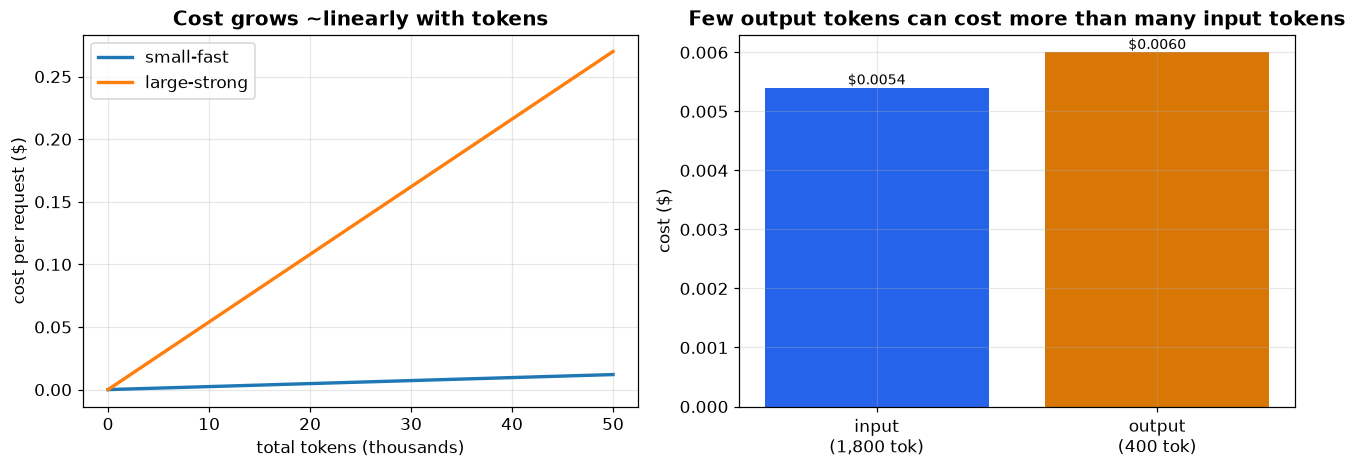

In [49]:


# Visualize cost growth and the input/output split.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) Cost vs total tokens for both models.
tot = np.linspace(0, 50_000, 100)
for name, p in PRICES.items():
    # assume 80% input / 20% output for the curve
    cost = estimate_cost(0.8*tot, 0.2*tot, p["in"], p["out"])
    axes[0].plot(tot/1000, cost, label=name, lw=2.2)
axes[0].set_title("Cost grows ~linearly with tokens")
axes[0].set_xlabel("total tokens (thousands)"); axes[0].set_ylabel("cost per request ($)")
axes[0].legend()

# (b) Input vs output cost share for a typical request on the strong model.
p = PRICES["large-strong"]
in_cost = (1800/1e6)*p["in"]; out_cost = (400/1e6)*p["out"]
axes[1].bar(["input\n(1,800 tok)", "output\n(400 tok)"], [in_cost, out_cost],
            color=[PAL["blue"], PAL["amber"]])
axes[1].set_title("Few output tokens can cost more than many input tokens")
axes[1].set_ylabel("cost ($)")
for i, v in enumerate([in_cost, out_cost]):
    axes[1].text(i, v, f"${v:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


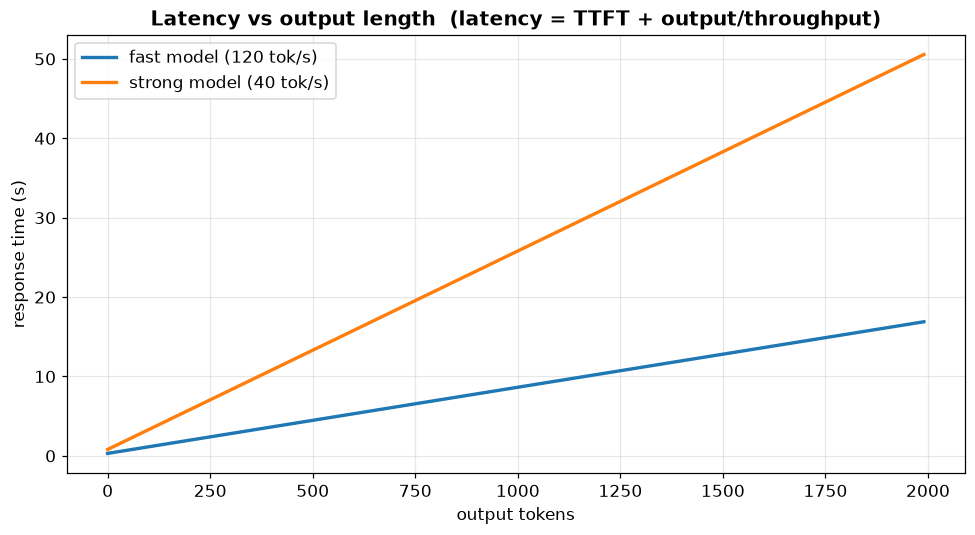

Cheapest speed win: cap max_tokens and ask for concise answers.


In [50]:

# Latency intuition: output length usually dominates.
out_tokens = np.arange(0, 2000, 10)
for ttft, tps, label in [(0.3, 120, "fast model (120 tok/s)"),
                         (0.8, 40, "strong model (40 tok/s)")]:
    latency = ttft + out_tokens / tps
    plt.plot(out_tokens, latency, lw=2.2, label=label)
plt.title("Latency vs output length  (latency = TTFT + output/throughput)")
plt.xlabel("output tokens"); plt.ylabel("response time (s)"); plt.legend()
plt.tight_layout(); plt.show()
print("Cheapest speed win: cap max_tokens and ask for concise answers.")


## 5. Prompt engineering

A prompt is a **program written in natural language**. Small wording changes can swing quality enormously. The good news: a handful of reliable techniques cover most needs.

### 5.1 Core techniques
| Technique | Idea | When to use |
|---|---|---|
| **Zero-shot** | just ask | simple, well-known tasks |
| **One-shot / few-shot** | show 1–N input→output examples | format matters, or the task is fuzzy |
| **Role prompting** | "You are a senior auditor…" | sets tone, depth, and vocabulary |
| **Delimiters** | fence inputs in ```...``` or `<doc>...</doc>` | separate instructions from data (also safer) |
| **Output constraints** | "Answer ONLY with valid JSON: {…}" | machine-readable, parseable replies |
| **Prompt templates** | reusable strings with slots | consistency + versioning |
| **Prompt chaining** | split a hard task into steps | each step is simpler and checkable |
| **Prompt compression** | summarize history / shrink context | fit the window, cut cost |

### 5.2 What makes prompts work
1. **Be specific** about task, audience, format, and length.
2. **Show, don't just tell** — one good example beats a paragraph of instructions.
3. **Separate instructions from data** with delimiters (clarity *and* injection safety).
4. **Constrain the output** so you can parse it reliably.
5. **Iterate**: change one thing at a time and compare.

### 5.3 Debugging prompts
When output is wrong, check in this order: ambiguous instruction → missing example → no output format → context too long (truncated) → wrong model/temperature.


=== WEAK prompt (score 0/6) ===
Tell me about this review.
  {'clear task verb': 'no', 'role / persona': 'no', 'delimiters': 'no', 'explicit output format': 'no', 'has example(s)': 'no', 'constraint (length/scope)': 'no'} 

=== STRONG prompt (score 6/6) ===
You are a precise review analyst. Classify the sentiment of the review delimited by triple
backticks. Answer ONLY as JSON with keys sentiment (positive/negative/neutral) and score
(0-1). Be concise. Example -> input: ```great value``` output:
{"sentiment":"positive","score":0.9}. Review: ```the delivery was slow but the product is
excellent```
  {'clear task verb': 'yes', 'role / persona': 'yes', 'delimiters': 'yes', 'explicit output format': 'yes', 'has example(s)': 'yes', 'constraint (length/scope)': 'yes'} 



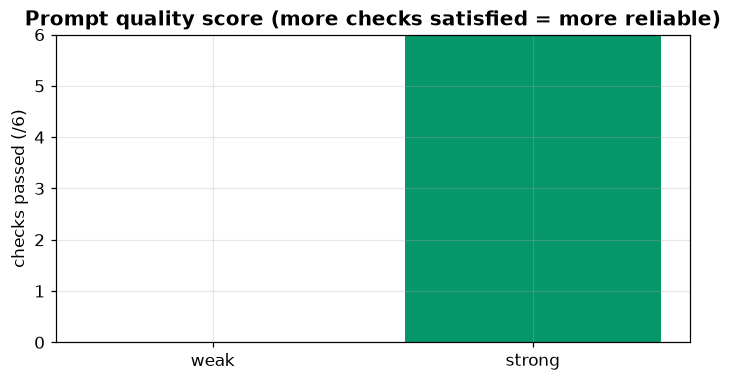

In [51]:

# "Before/after": score prompt QUALITY on concrete dimensions (runnable rubric).
def score_prompt(text):
    t = text.lower()
    checks = {
        "clear task verb": any(v in t for v in ["classify", "summarize", "extract", "write", "answer", "rate"]),
        "role / persona": any(v in t for v in ["you are", "act as", "as a "]),
        "delimiters": ("```" in text) or ("<" in text and ">" in text),
        "explicit output format": any(v in t for v in ["json", "format", "bullet", "one sentence", "schema"]),
        "has example(s)": ("example" in t) or ("e.g." in t) or ("input:" in t and "output:" in t),
        "constraint (length/scope)": any(v in t for v in ["only", "max", "at most", "no more than", "concise"]),
    }
    return checks, sum(checks.values())

weak = "Tell me about this review."
strong = (
    "You are a precise review analyst. Classify the sentiment of the review delimited by triple "
    "backticks. Answer ONLY as JSON with keys sentiment (positive/negative/neutral) and score (0-1). "
    "Be concise. Example -> input: ```great value``` output: {\"sentiment\":\"positive\",\"score\":0.9}. "
    "Review: ```the delivery was slow but the product is excellent```"
)

for label, p in [("WEAK", weak), ("STRONG", strong)]:
    checks, total = score_prompt(p)
    print(f"=== {label} prompt (score {total}/6) ===")
    print(textwrap.fill(p, 90))
    print(" ", {k: ("yes" if v else "no") for k, v in checks.items()}, "\n")

# Bar chart of the two scores.
plt.figure(figsize=(6.5, 3.6))
plt.bar(["weak", "strong"], [score_prompt(weak)[1], score_prompt(strong)[1]],
        color=[PAL["red"], PAL["green"]])
plt.title("Prompt quality score (more checks satisfied = more reliable)")
plt.ylabel("checks passed (/6)"); plt.ylim(0, 6)
plt.tight_layout(); plt.show()


In [52]:

# Illustrative before/after OUTPUT (responders mimic typical model behaviour).
def vague_responder(_):
    return ("Well, reviews can mean many things and sentiment is complex; this one seems "
            "kind of mixed, maybe leaning positive, but it depends on what you care about...")
def structured_responder(_):
    return "{\"sentiment\": \"positive\", \"score\": 0.78}"

print("Vague prompt ->\n", textwrap.fill(
    chat([{"role": "user", "content": "Tell me about this review."}],
         responder=vague_responder)["choices"][0]["message"]["content"], 88))
print("\nStructured prompt ->\n",
    chat([{"role": "user", "content": "Classify as JSON ..."}],
         responder=structured_responder)["choices"][0]["message"]["content"])
print("\n(The second is parseable, testable, and safe to use downstream.)")


Vague prompt ->
 Well, reviews can mean many things and sentiment is complex; this one seems kind of
mixed, maybe leaning positive, but it depends on what you care about...

Structured prompt ->
 {"sentiment": "positive", "score": 0.78}

(The second is parseable, testable, and safe to use downstream.)


In [53]:

# Few-shot template builder: assemble a clean prompt from examples + a query.
def build_few_shot(task, examples, query):
    lines = [task, ""]
    for ex in examples:
        lines.append("Input: " + ex["input"])
        lines.append("Output: " + ex["output"])
        lines.append("")
    lines.append("Input: " + query)
    lines.append("Output:")
    return "\n".join(lines)

examples = [
    {"input": "I love this!", "output": "positive"},
    {"input": "Worst purchase ever.", "output": "negative"},
]
prompt = build_few_shot("Classify sentiment as positive/negative.", examples, "It is okay, nothing special.")
print(prompt)


Classify sentiment as positive/negative.

Input: I love this!
Output: positive

Input: Worst purchase ever.
Output: negative

Input: It is okay, nothing special.
Output:


In [54]:

# Prompt CHAINING: split a hard task into simple, inspectable steps.
text = "Acme Corp raised $40M in Series B led by Globex to expand its Berlin office in 2025."

def extract_responder(_):     # step 1: structured extraction
    return json.dumps({"company": "Acme Corp", "amount": "$40M", "round": "Series B",
                       "investor": "Globex", "city": "Berlin", "year": 2025})
def headline_responder(_):    # step 3: format
    return "Acme Corp lands $40M Series B (led by Globex) to grow Berlin team."

facts = json.loads(chat([{"role": "user", "content": "Extract facts as JSON: " + text}],
                        responder=extract_responder)["choices"][0]["message"]["content"])
print("Step 1 - extracted facts:", facts)

verified = {k: v for k, v in facts.items() if v}   # step 2: simple validation/transform
print("Step 2 - validated fields:", list(verified))

headline = chat([{"role": "user", "content": "Write a headline from: " + json.dumps(verified)}],
                responder=headline_responder)["choices"][0]["message"]["content"]
print("Step 3 - headline:", headline)
print("\nChaining makes each step easy to test, cache, and debug independently.")


Step 1 - extracted facts: {'company': 'Acme Corp', 'amount': '$40M', 'round': 'Series B', 'investor': 'Globex', 'city': 'Berlin', 'year': 2025}
Step 2 - validated fields: ['company', 'amount', 'round', 'investor', 'city', 'year']
Step 3 - headline: Acme Corp lands $40M Series B (led by Globex) to grow Berlin team.

Chaining makes each step easy to test, cache, and debug independently.


## 6. Sampling & generation controls

The model outputs a **probability distribution over the next token**. *How you pick* from that distribution controls whether output is focused or creative, repetitive or varied, reproducible or surprising. This is the most visual section — we will plot the distributions directly.

### 6.1 The knobs
| Parameter | Effect | Lower → / Higher → |
|---|---|---|
| **Temperature** `T` | sharpens or flattens the distribution | focused, deterministic → diverse, random |
| **Top-k** | sample only from the `k` most likely tokens | safer, narrower → broader |
| **Top-p (nucleus)** | sample from the smallest set with cumulative prob ≥ `p` | tighter → looser |
| **max_tokens** | hard cap on output length | (controls cost & latency) |
| **stop sequences** | strings that end generation | clean cutoffs |
| **repetition / frequency penalty** | discourage repeats | reduces loops/echoing |

**Temperature** rescales the logits before softmax:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

As `T → 0` this becomes **greedy** (always the top token); `T = 1` is the model's "natural" distribution; `T > 1` flattens it toward random.

### 6.2 Deterministic vs stochastic
- **Deterministic** (`T → 0`, or greedy/beam search): reproducible — good for extraction, classification, code, anything you will parse or test.
- **Stochastic** (`T`/top-p sampling): varied — good for brainstorming, writing, multiple candidate generation.
- **Beam search** (high level): keeps several partial sequences and extends the best — favors high-probability, "safe" text; common in translation, less so in open chat.


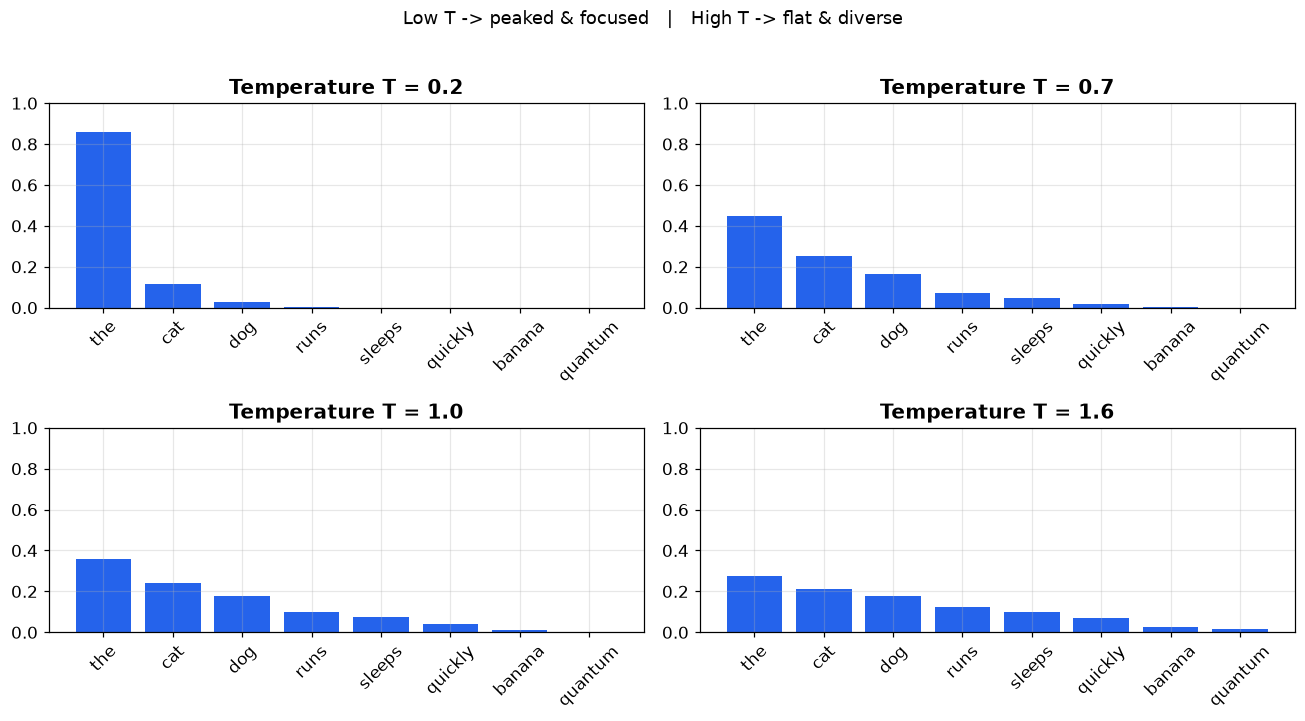

In [55]:

# Temperature: same logits, different sharpness. We plot the resulting distributions.
vocab  = ["the", "cat", "dog", "runs", "sleeps", "quickly", "banana", "quantum"]
logits = np.array([3.2, 2.8, 2.5, 1.9, 1.6, 1.0, -0.5, -1.5])

def softmax(z, T=1.0):
    z = np.asarray(z, float) / max(T, 1e-6)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))
for ax, T in zip(axes.ravel(), [0.2, 0.7, 1.0, 1.6]):
    p = softmax(logits, T)
    ax.bar(vocab, p, color=PAL["blue"])
    ax.set_title(f"Temperature T = {T}")
    ax.set_ylim(0, 1); ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Low T -> peaked & focused   |   High T -> flat & diverse", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


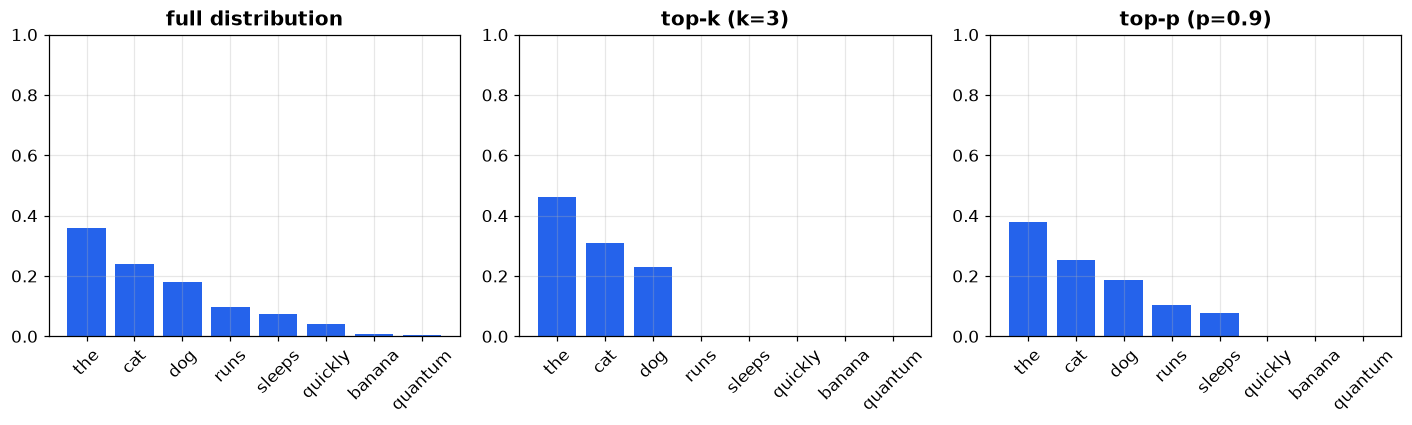

Tokens with zero bars were pruned; the survivors are renormalized to sum to 1.
top-k keeps a FIXED count; top-p keeps a VARIABLE count sized to the probability mass.


In [56]:

# Top-k and top-p both PRUNE the tail, then renormalize -- shown side by side.
p = softmax(logits, T=1.0)

def top_k_filter(probs, k):
    keep = np.argsort(-probs)[:k]
    out = np.zeros_like(probs); out[keep] = probs[keep]
    return out / out.sum()

def top_p_filter(probs, p_thresh):
    order = np.argsort(-probs)
    cum = np.cumsum(probs[order])
    n_keep = int(np.searchsorted(cum, p_thresh) + 1)
    keep = order[:n_keep]
    out = np.zeros_like(probs); out[keep] = probs[keep]
    return out / out.sum()

pk = top_k_filter(p, k=3)
pp = top_p_filter(p, 0.9)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, dist, title in [(axes[0], p, "full distribution"),
                        (axes[1], pk, "top-k (k=3)"),
                        (axes[2], pp, "top-p (p=0.9)")]:
    colors = [PAL["blue"] if v > 0 else PAL["lred"] for v in dist]
    ax.bar(vocab, dist, color=colors)
    ax.set_title(title); ax.set_ylim(0, 1); ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
print("Tokens with zero bars were pruned; the survivors are renormalized to sum to 1.")
print("top-k keeps a FIXED count; top-p keeps a VARIABLE count sized to the probability mass.")


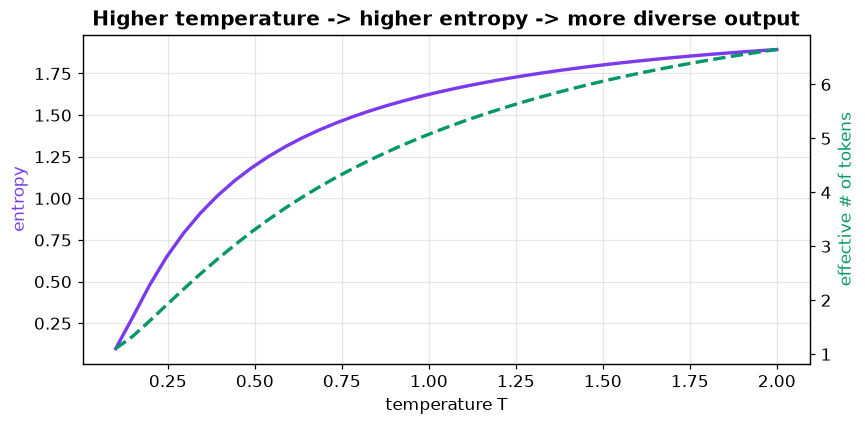

T=0.2: the cat the cat the the the the the the the the the the the the the the   (2 distinct)
T=1.5: the the runs the cat banana quickly runs dog the the banana dog the dog runs dog quickly   (6 distinct)


In [57]:

# Diversity vs temperature: entropy + a concrete sampling demo.
Ts = np.linspace(0.1, 2.0, 40)
entropy = [-(softmax(logits, T) * np.log(softmax(logits, T) + 1e-12)).sum() for T in Ts]
eff_tokens = np.exp(entropy)  # "effective number of choices" (perplexity)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(Ts, entropy, color=PAL["purple"], lw=2.2, label="entropy (nats)")
ax1.set_xlabel("temperature T"); ax1.set_ylabel("entropy", color=PAL["purple"])
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(Ts, eff_tokens, color=PAL["green"], lw=2.2, ls="--", label="effective # choices")
ax2.set_ylabel("effective # of tokens", color=PAL["green"])
ax1.set_title("Higher temperature -> higher entropy -> more diverse output")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(1)
for T in [0.2, 1.5]:
    draws = rng.choice(vocab, size=18, p=softmax(logits, T))
    print(f"T={T:>3}: {' '.join(draws)}   ({len(set(draws))} distinct)")


## 7. Reasoning techniques

For multi-step problems, *how you ask the model to think* matters. These are **prompting / workflow patterns**, not new intelligence — they trade extra tokens (and latency) for more reliable reasoning. Use them where steps help; skip them for simple lookups.

| Pattern | Idea | Helps with | Cost |
|---|---|---|---|
| **Chain of Thought (CoT)** | ask for step-by-step reasoning | math, logic, multi-hop | more output tokens |
| **ReAct** | interleave **Reason → Act (tool) → Observe** | tasks needing tools / live data | loop overhead |
| **Tree/Graph of Thoughts** | branch and explore multiple paths | search-like problems | expensive |


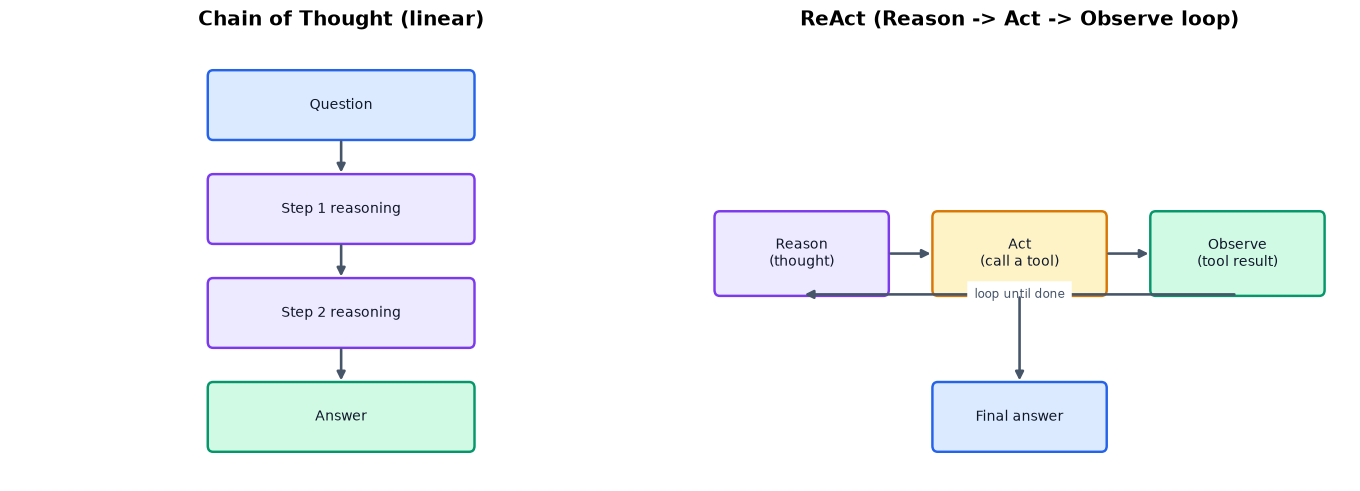

In [21]:

# CoT vs ReAct, side by side.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]; ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off"); ax.grid(False)
ax.set_title("Chain of Thought (linear)")
add_box(ax, 3, 4.6, 4, 0.9, "Question", fc=PAL["lblue"], ec=PAL["blue"], fs=9)
add_box(ax, 3, 3.2, 4, 0.9, "Step 1 reasoning", fc=PAL["lpurple"], ec=PAL["purple"], fs=9)
add_box(ax, 3, 1.8, 4, 0.9, "Step 2 reasoning", fc=PAL["lpurple"], ec=PAL["purple"], fs=9)
add_box(ax, 3, 0.4, 4, 0.9, "Answer", fc=PAL["lgreen"], ec=PAL["green"], fs=9)
for y0, y1 in [(4.6, 4.1), (3.2, 2.7), (1.8, 1.3)]:
    add_arrow(ax, 5, y0, 5, y1)

ax = axes[1]; ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off"); ax.grid(False)
ax.set_title("ReAct (Reason -> Act -> Observe loop)")
add_box(ax, 0.4, 2.5, 2.6, 1.1, "Reason\n(thought)", fc=PAL["lpurple"], ec=PAL["purple"], fs=9)
add_box(ax, 3.7, 2.5, 2.6, 1.1, "Act\n(call a tool)", fc=PAL["lamber"], ec=PAL["amber"], fs=9)
add_box(ax, 7.0, 2.5, 2.6, 1.1, "Observe\n(tool result)", fc=PAL["lgreen"], ec=PAL["green"], fs=9)
add_arrow(ax, 3.0, 3.05, 3.7, 3.05)
add_arrow(ax, 6.3, 3.05, 7.0, 3.05)
add_arrow(ax, 8.3, 2.5, 1.7, 2.5, text="loop until done", color=PAL["slate"])
add_box(ax, 3.7, 0.4, 2.6, 0.9, "Final answer", fc=PAL["lblue"], ec=PAL["blue"], fs=9)
add_arrow(ax, 5.0, 2.5, 5.0, 1.3)
plt.tight_layout(); plt.show()


## 8. Embeddings

> **What it is.** An **embedding** is a list of numbers (a *vector*) that captures the *meaning* of a piece of text. Texts with similar meaning get vectors that point in similar directions — even when they share **no words**.

> **Why it matters.** Embeddings turn "is this about the same thing?" into simple geometry. That single idea powers **semantic search, clustering, classification, deduplication, recommendation**, and — most importantly for us — the **retrieval** step in RAG.

**The core primitive — cosine similarity.** Two vectors $a$ and $b$ are compared by the cosine of the angle between them:

$$\text{cosine}(a,b)=\frac{a\cdot b}{\lVert a\rVert\,\lVert b\rVert}\in[-1,1]$$

$1$ means "same direction" (very similar), $0$ means "unrelated". If vectors are **normalized** to unit length, cosine similarity is just the dot product — which is why vector stores can search millions of items so fast.

| Task | How embeddings solve it |
|---|---|
| **Semantic search** | Embed query + documents, return the nearest documents |
| **Clustering** | Group vectors that sit close together (e.g. K-Means) |
| **Classification** | Nearest labelled neighbours vote on the label |
| **Deduplication** | Near-identical vectors = duplicate content |
| **Retrieval (RAG)** | Find the few chunks most relevant to a question |

*This notebook embeds text with a real sentence-transformer when available, and automatically falls back to TF-IDF so every cell still runs offline. The backend name is printed so you always know which one produced a result.*


### 8.1 Embeddings vs classic sparse representations

The previous NLP session used **sparse** representations like **bag-of-words** and **TF-IDF** (Term Frequency–Inverse Document Frequency): one dimension per vocabulary word, mostly zeros. They are fast and interpretable but match on **exact words**, so *"car"* and *"automobile"* look unrelated.

**Dense embeddings** from a trained model use a few hundred dimensions where every number carries learned meaning, so paraphrases land close together.

| | Sparse (TF-IDF / BM25) | Dense embeddings |
|---|---|---|
| Dimensions | Thousands (vocabulary size) | Hundreds (learned) |
| Matches on | Exact words / overlap | **Meaning / paraphrase** |
| "car" vs "automobile" | Unrelated | Close |
| Cost | Almost free | Needs a model |
| Best at | Rare keywords, codes, IDs | Concepts, synonyms |

**Takeaway:** they are complementary. Production retrieval often combines both (**hybrid search**, covered in the RAG section). *If this notebook fell back to TF-IDF, the demos above used the sparse method — the geometry still works because the example sentences share topical vocabulary.*


## 9. Vector databases

> **What it is.** A **vector database** stores embeddings and answers the question *"which stored vectors are nearest to this query vector?"* in milliseconds — across millions of items.

> **Why it matters.** Comparing a query against every vector (a *brute-force scan*) is fine for hundreds of items but far too slow at scale. Vector databases add an **index** (an **ANN** — *Approximate Nearest Neighbor* — structure) that finds the closest vectors without checking them all, trading a tiny bit of accuracy for enormous speed.

**What they provide beyond raw search:**
- **ANN indexing** (e.g. **HNSW** — *Hierarchical Navigable Small World* graphs) for sub-linear search.
- **Metadata filtering** — restrict by attributes ("only docs from 2024", "only this user").
- **Persistence & scaling** — durable storage, sharding, replication.
- **CRUD on vectors** — add, update, and delete documents as your corpus changes.

| Store | Shape | Notes |
|---|---|---|
| **FAISS** | Library | Meta's fast in-process index; you manage storage yourself |
| **Chroma** | Library / server | Developer-friendly, great for local prototyping |
| **Pinecone** | Managed cloud | Fully hosted, scales without ops work |
| **Qdrant** | Server | Rust, strong metadata filtering + payloads |

In [22]:

# Nearest-neighbor retrieval with our tiny in-memory index (same idea as FAISS/Chroma).
docs = [
    "Python is a popular programming language for data science and AI.",
    "The Eiffel Tower is a landmark located in Paris, France.",
    "Photosynthesis lets plants convert sunlight into chemical energy.",
    "Transformers are the neural architecture behind modern language models.",
    "Mount Everest is the highest mountain above sea level on Earth.",
    "Pandas and NumPy are core Python libraries for data analysis.",
]
index = SemanticIndex(docs)
print("Index backend:", index.backend, "| documents indexed:", len(docs), "\n")

for q in ["Which tools do I use for data analysis in Python?",
          "Tell me about a famous tall mountain."]:
    print("QUERY:", q)
    for hit in index.search(q, k=2):
        print(f"   #{hit['rank']}  score={hit['score']:.3f}  ->  {hit['text']}")
    print()


C:\Users\ibrah\Desktop\AI-Camp\5-LLM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1719.21it/s]


Index backend: sentence-transformers (all-MiniLM-L6-v2) | documents indexed: 6 

QUERY: Which tools do I use for data analysis in Python?
   #1  score=0.778  ->  Pandas and NumPy are core Python libraries for data analysis.
   #2  score=0.619  ->  Python is a popular programming language for data science and AI.

QUERY: Tell me about a famous tall mountain.
   #1  score=0.567  ->  Mount Everest is the highest mountain above sea level on Earth.
   #2  score=0.199  ->  The Eiffel Tower is a landmark located in Paris, France.



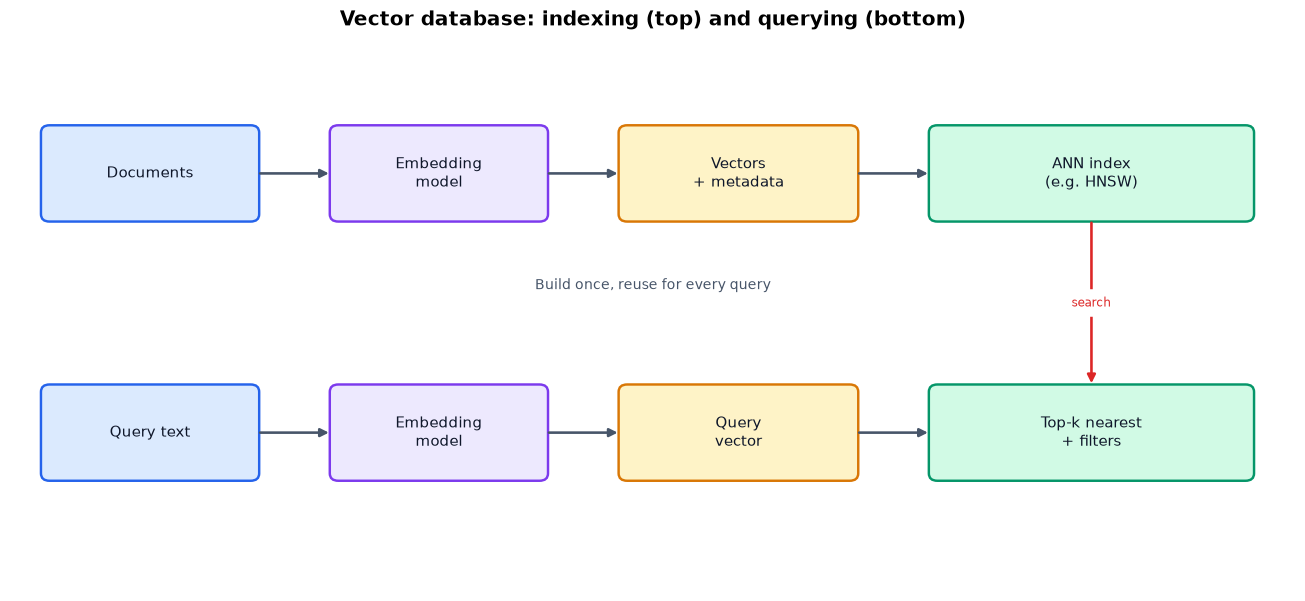

In [24]:

# Diagram: how a vector database indexes documents and serves a query.
fig, ax = blank_canvas(12, 5.6, xlim=12, ylim=6,
                       title="Vector database: indexing (top) and querying (bottom)")

# Indexing row
add_box(ax, 0.3, 4.0, 2.0, 1.0, "Documents", PAL["lblue"], PAL["blue"])
add_box(ax, 3.0, 4.0, 2.0, 1.0, "Embedding\nmodel", PAL["lpurple"], PAL["purple"])
add_box(ax, 5.7, 4.0, 2.2, 1.0, "Vectors\n+ metadata", PAL["lamber"], PAL["amber"])
add_box(ax, 8.6, 4.0, 3.0, 1.0, "ANN index\n(e.g. HNSW)", PAL["lgreen"], PAL["green"])
add_arrow(ax, 2.3, 4.5, 3.0, 4.5)
add_arrow(ax, 5.0, 4.5, 5.7, 4.5)
add_arrow(ax, 7.9, 4.5, 8.6, 4.5)

# Querying row
add_box(ax, 0.3, 1.2, 2.0, 1.0, "Query text", PAL["lblue"], PAL["blue"])
add_box(ax, 3.0, 1.2, 2.0, 1.0, "Embedding\nmodel", PAL["lpurple"], PAL["purple"])
add_box(ax, 5.7, 1.2, 2.2, 1.0, "Query\nvector", PAL["lamber"], PAL["amber"])
add_box(ax, 8.6, 1.2, 3.0, 1.0, "Top-k nearest\n+ filters", PAL["lgreen"], PAL["green"])
add_arrow(ax, 2.3, 1.7, 3.0, 1.7)
add_arrow(ax, 5.0, 1.7, 5.7, 1.7)
add_arrow(ax, 7.9, 1.7, 8.6, 1.7)

# Link query into the index
add_arrow(ax, 10.1, 4.0, 10.1, 2.2, text="search", color=PAL["red"])
ax.text(6, 3.25, "Build once, reuse for every query", ha="center", fontsize=9, color=PAL["slate"])
plt.tight_layout(); plt.show()


## 10. Retrieval-Augmented Generation (RAG)

> **What it is.** **RAG** gives an LLM *open-book access* to your data: before answering, the system **retrieves** the most relevant text and pastes it into the prompt as context. The model answers **from that context** instead of from memory alone.

> **Why it matters.** It is the most practical way to make an LLM answer about **private, current, or niche** information — your docs, your tickets, last week's reports — **without fine-tuning**, while reducing hallucinations and letting you **cite sources**.

**RAG vs fine-tuning, in one line:** RAG injects *knowledge* at query time (easy to update); fine-tuning changes *behaviour/style* by retraining (covered next). For "the model should *know* this fact," reach for RAG first.

### 10.1 The pipeline
Indexing (offline, once): **load → clean → chunk → embed → index**.
Querying (online, per question): **embed query → retrieve → (rerank) → assemble prompt → generate → ground & cite**.


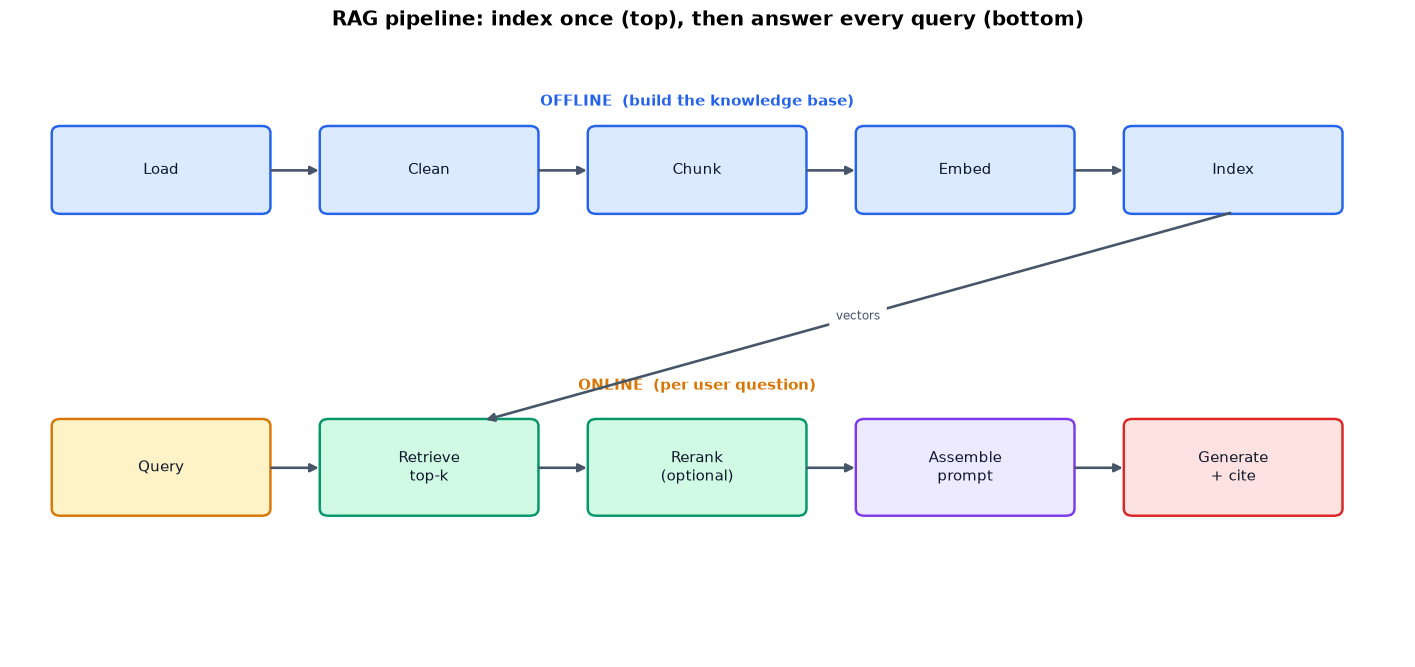

In [25]:

# Flowchart of the full RAG pipeline: offline indexing (top) + online answering (bottom).
fig, ax = blank_canvas(13, 6.2, xlim=13, ylim=7,
                       title="RAG pipeline: index once (top), then answer every query (bottom)")

idx_stages = ["Load", "Clean", "Chunk", "Embed", "Index"]
for i, s in enumerate(idx_stages):
    x = 0.4 + i*2.5
    add_box(ax, x, 5.0, 2.0, 0.95, s, PAL["lblue"], PAL["blue"])
    if i < len(idx_stages) - 1:
        add_arrow(ax, x+2.0, 5.47, x+2.5, 5.47)
ax.text(6.4, 6.2, "OFFLINE  (build the knowledge base)", ha="center", fontsize=10,
        color=PAL["blue"], weight="bold")

qry_stages = [("Query", PAL["lamber"], PAL["amber"]),
              ("Retrieve\ntop-k", PAL["lgreen"], PAL["green"]),
              ("Rerank\n(optional)", PAL["lgreen"], PAL["green"]),
              ("Assemble\nprompt", PAL["lpurple"], PAL["purple"]),
              ("Generate\n+ cite", PAL["lred"], PAL["red"])]
for i, (s, fc, ec) in enumerate(qry_stages):
    x = 0.4 + i*2.5
    add_box(ax, x, 1.6, 2.0, 1.05, s, fc, ec)
    if i < len(qry_stages) - 1:
        add_arrow(ax, x+2.0, 2.12, x+2.5, 2.12)
ax.text(6.4, 3.0, "ONLINE  (per user question)", ha="center", fontsize=10,
        color=PAL["amber"], weight="bold")

# Index feeds the retrieve step.
add_arrow(ax, 11.4, 5.0, 4.4, 2.65, text="vectors", color=PAL["slate"])
plt.tight_layout(); plt.show()


### 10.2 Chunking — the most underrated knob

You cannot embed a 50-page document as one vector and hope to retrieve a precise answer. You split it into **chunks** and embed each one. Two parameters dominate quality:

- **Chunk size** — how much text per chunk.
- **Chunk overlap** — how much consecutive chunks share, so ideas split across a boundary still appear intact in at least one chunk.

The trade-off: **small chunks** are precise but may lack surrounding context; **large chunks** carry more context but dilute relevance (the matching sentence is buried among unrelated text) and cost more tokens. Most applications land at a few hundred tokens with modest overlap, then tune by measuring retrieval quality.


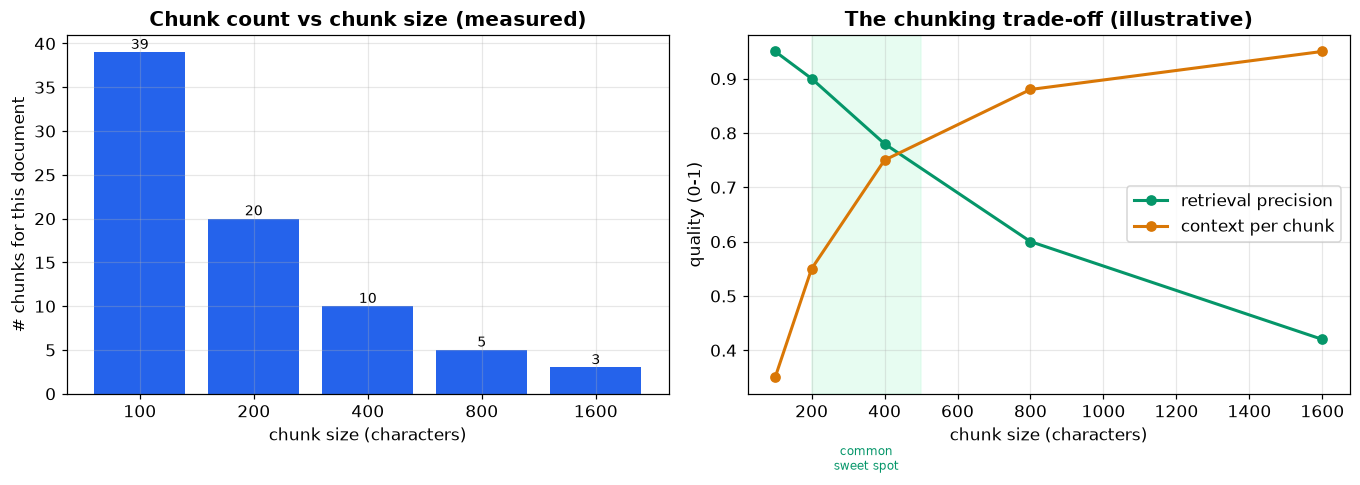

Smaller chunks -> more chunks + sharper matches; larger chunks -> more context, fuzzier matches.


In [26]:

# Real chunking on a sample document: see how chunk size changes the chunk count,
# alongside an illustrative view of the precision/context trade-off.
sample_doc = (
    "Retrieval augmented generation combines search with generation. "
    "First documents are split into chunks. Each chunk is embedded into a vector. "
    "The vectors are stored in an index for fast similarity search. "
    "At query time the question is embedded and compared to every chunk. "
    "The closest chunks are retrieved and inserted into the prompt as context. "
    "The model then answers using that context and can cite its sources. "
    "Good chunking keeps related ideas together without diluting relevance. "
    "Overlap helps when an idea is split across a chunk boundary."
) * 6  # repeat to make a longer document

def chunk_text(text, chunk_size, overlap):
    # Character-based chunking with overlap (token chunking works the same way).
    step = max(1, chunk_size - overlap)
    return [text[i:i+chunk_size] for i in range(0, len(text), step) if text[i:i+chunk_size]]

sizes = [100, 200, 400, 800, 1600]
counts = [len(chunk_text(sample_doc, s, int(0.15*s))) for s in sizes]
# Illustrative quality curves (not measured): precision falls, context rises with size.
precision = np.array([0.95, 0.90, 0.78, 0.60, 0.42])
context   = np.array([0.35, 0.55, 0.75, 0.88, 0.95])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].bar([str(s) for s in sizes], counts, color=PAL["blue"])
axes[0].set_title("Chunk count vs chunk size (measured)")
axes[0].set_xlabel("chunk size (characters)"); axes[0].set_ylabel("# chunks for this document")
for i, c in enumerate(counts):
    axes[0].text(i, c, str(c), ha="center", va="bottom", fontsize=9)

axes[1].plot(sizes, precision, "o-", color=PAL["green"], lw=2, label="retrieval precision")
axes[1].plot(sizes, context, "o-", color=PAL["amber"], lw=2, label="context per chunk")
axes[1].axvspan(200, 500, color=PAL["lgreen"], alpha=0.5)
axes[1].set_title("The chunking trade-off (illustrative)")
axes[1].set_xlabel("chunk size (characters)"); axes[1].set_ylabel("quality (0-1)")
axes[1].text(350, 0.18, "common\nsweet spot", ha="center", fontsize=8, color=PAL["green"])
axes[1].legend()
plt.tight_layout(); plt.show()
print("Smaller chunks -> more chunks + sharper matches; larger chunks -> more context, fuzzier matches.")


In [27]:

# End-to-end MINI RAG: retrieve relevant chunks, build a grounded prompt, generate an answer.
knowledge_base = [
    "Our refund policy allows returns within 30 days of purchase with a receipt.",
    "Standard shipping takes 3 to 5 business days within the continental US.",
    "Premium members get free two-day shipping on all eligible orders.",
    "The support team is available Monday to Friday, 9am to 6pm Eastern time.",
    "Gift cards are non-refundable and cannot be exchanged for cash.",
    "Damaged items can be replaced free of charge within 14 days of delivery.",
]
rag_index = SemanticIndex(knowledge_base)

def assemble_prompt(question, contexts):
    # Number the retrieved chunks so the model can cite them as [1], [2], ...
    numbered = "\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    instructions = (
        "Answer the question using ONLY the context below. "
        "Cite sources as [n]. If the context does not contain the answer, say you do not know."
    )
    return instructions + "\n\nContext:\n" + numbered + "\n\nQuestion: " + question

def grounded_responder(messages):
    # A stand-in 'generator': pulls the sentence in context most similar to the question
    # and returns it with a citation. A real LLM would phrase a fluent answer here.
    prompt = messages[-1]["content"]
    q = prompt.split("Question:")[-1].strip()
    ctx_lines = [ln for ln in prompt.splitlines() if ln.strip().startswith("[")]
    if not ctx_lines:
        return "I don't know based on the provided context."
    ctx_texts = [ln.split("] ", 1)[-1] for ln in ctx_lines]
    # Embed the query and the contexts TOGETHER so they share one vector space
    # (works whether the backend is neural or the offline TF-IDF fallback).
    V = embed_texts([q] + ctx_texts)[0]
    qv, cvecs = V[0], V[1:]
    sims = cvecs @ qv
    best = int(np.argmax(sims))
    if float(sims[best]) < 0.05:
        return "I don't know based on the provided context."
    tag = ctx_lines[best].split("]")[0] + "]"
    return ctx_texts[best] + f" {tag}"

def rag_answer(question, k=3, show=True):
    hits = rag_index.search(question, k=k)
    contexts = [h["text"] for h in hits]
    prompt = assemble_prompt(question, contexts)
    out = chat([{"role": "user", "content": prompt}], responder=grounded_responder)
    answer = out["choices"][0]["message"]["content"]
    if show:
        print("QUESTION:", question)
        print("RETRIEVED:")
        for h in hits:
            print(f"   score={h['score']:.3f}  {h['text']}")
        print("ANSWER:", answer)
        print("tokens:", out["usage"], "\n")
    return answer

_ = rag_answer("How long do I have to return something?")
_ = rag_answer("Do premium members get faster shipping?")


QUESTION: How long do I have to return something?
RETRIEVED:
   score=0.732  Our refund policy allows returns within 30 days of purchase with a receipt.
   score=0.485  Damaged items can be replaced free of charge within 14 days of delivery.
   score=0.290  Standard shipping takes 3 to 5 business days within the continental US.
ANSWER: Our refund policy allows returns within 30 days of purchase with a receipt. [1]
tokens: {'prompt_tokens': 107, 'completion_tokens': 20, 'total_tokens': 127} 

QUESTION: Do premium members get faster shipping?
RETRIEVED:
   score=0.754  Premium members get free two-day shipping on all eligible orders.
   score=0.425  Standard shipping takes 3 to 5 business days within the continental US.
   score=0.240  Damaged items can be replaced free of charge within 14 days of delivery.
ANSWER: Premium members get free two-day shipping on all eligible orders. [1]
tokens: {'prompt_tokens': 105, 'completion_tokens': 17, 'total_tokens': 122} 



In [28]:

# GOOD vs BAD retrieval: when nothing relevant exists, a grounded system should ABSTAIN.
print("=== In-scope question (relevant context exists) ===")
_ = rag_answer("What are the support team's hours?", k=2)

print("=== Out-of-scope question (no relevant context) ===")
_ = rag_answer("What is the capital of Australia?", k=2)
print("Because retrieved scores are low and the fact is absent, the grounded answer is 'I don't know'.")
print("This abstention is the single biggest lever for reducing hallucinations in RAG.")


=== In-scope question (relevant context exists) ===
QUESTION: What are the support team's hours?
RETRIEVED:
   score=0.743  The support team is available Monday to Friday, 9am to 6pm Eastern time.
   score=0.247  Premium members get free two-day shipping on all eligible orders.
ANSWER: The support team is available Monday to Friday, 9am to 6pm Eastern time. [1]
tokens: {'prompt_tokens': 84, 'completion_tokens': 19, 'total_tokens': 103} 

=== Out-of-scope question (no relevant context) ===
QUESTION: What is the capital of Australia?
RETRIEVED:
   score=0.061  Standard shipping takes 3 to 5 business days within the continental US.
   score=0.004  Premium members get free two-day shipping on all eligible orders.
ANSWER: Standard shipping takes 3 to 5 business days within the continental US. [1]
tokens: {'prompt_tokens': 84, 'completion_tokens': 19, 'total_tokens': 103} 

Because retrieved scores are low and the fact is absent, the grounded answer is 'I don't know'.
This abstention is the 

### 10.3 Beyond the basics

- **Dense vs sparse retrieval.** *Dense* (embeddings) matches meaning; *sparse* (**BM25** — a classic keyword-ranking function) matches exact terms and excels at rare words, names, codes, and IDs.
- **Hybrid retrieval.** Combine dense + sparse scores (then optionally **rerank**) to get the best of both. A small **cross-encoder reranker** re-scores the top candidates by reading the *(query, chunk)* pair together — slower but much more precise than the first-pass vector search.
- **Common failure modes.** Bad chunking (answer split across chunks) · missing documents (it was never indexed) · embedding mismatch (query and docs phrased very differently) · too few or too many chunks retrieved · stale index (the source changed but the index didn't).

### 10.4 Evaluating RAG
RAG quality splits cleanly into two halves you should measure **separately**:

| Stage | Question | Typical metric |
|---|---|---|
| **Retrieval** | Did we fetch the right chunks? | recall@k, precision@k, hit-rate |
| **Generation** | Did the answer stick to them? | **groundedness / faithfulness**, answer relevance |

If retrieval is broken, no amount of prompt tuning saves the answer — so debug retrieval **first**. We build small scorers for groundedness and relevance in the **Evaluation** section.


## 11. Fine-tuning

> **What it is.** **Fine-tuning** continues training a pretrained model on your own examples so its *weights* shift toward your task, format, or style. Unlike RAG (which adds knowledge at query time), fine-tuning **bakes behaviour into the model**.

> **Why it matters.** When you need a *consistent format*, a *specific tone/persona*, a *narrow skill done reliably*, or *shorter prompts* (because the instructions are now learned), fine-tuning can outperform prompting — and can let a smaller, cheaper model match a larger one on **your** task.

### 11.1 Choose the right tool first
Most "we need to fine-tune" instincts are better served by prompting or RAG. Climb this ladder and stop at the first rung that works:

| Need | Best tool | Why |
|---|---|---|
| Better instructions / format | **Prompt engineering** | Free, instant, no training |
| External / fresh / private facts | **RAG** | Update by changing data, not weights |
| Consistent style, format, or a narrow skill | **Fine-tuning** | Behaviour becomes reliable & promptless |
| Fresh facts **and** custom behaviour | **RAG + fine-tuning** | They solve different problems |

**When *not* to fine-tune:** the knowledge changes often (use RAG), you have few or low-quality examples, prompting already works, or you can't commit to evaluating and re-training as things drift.

### 11.2 Flavours (high level)
- **Supervised fine-tuning (SFT):** train on *(input → ideal output)* pairs. The workhorse for format and skills.
- **Instruction tuning:** SFT on many *(instruction → response)* pairs so a base model follows instructions broadly.
- **Preference tuning (RLHF / DPO):** train on *(chosen vs rejected)* pairs to align tone, helpfulness, and safety. **RLHF** = *Reinforcement Learning from Human Feedback*; **DPO** = *Direct Preference Optimization*, a simpler popular alternative.

### 11.3 Data & evaluation
Quality beats quantity: a few hundred clean, consistent, representative examples usually beat tens of thousands of noisy ones — and the model will faithfully imitate any mistakes in your data. **Always** hold out a test set and compare the fine-tuned model against the base model **before** shipping. The next section shows *how* to make this affordable.


## 12. LoRA and QLoRA

> **The problem.** *Full* fine-tuning updates **every** weight and must also store optimizer state for each one. For a 7-billion-parameter model that means tens of gigabytes of GPU memory — out of reach for most single GPUs.

> **The fix — PEFT.** **PEFT** (*Parameter-Efficient Fine-Tuning*) freezes the original weights and trains a **tiny** number of new ones. **LoRA** is the most popular PEFT method; **QLoRA** makes it cheaper still.

### 12.1 LoRA — *Low-Rank Adaptation*
Freeze the big weight matrix $W$ and learn a small **low-rank** update beside it:

$$W' = W + \Delta W,\qquad \Delta W = B\,A,\quad A\in\mathbb{R}^{r\times d_{in}},\; B\in\mathbb{R}^{d_{out}\times r}$$

with the **rank** $r$ tiny (e.g. 8 or 16). A full update to $W$ has $d_{out}\times d_{in}$ numbers; LoRA trains only $r\times(d_{in}+d_{out})$ — often **<1%** of them. You ship just the small adapters and can swap different ones onto the same base model.

### 12.2 QLoRA — *Quantized LoRA*
Load the **frozen** base model in **4-bit** precision (drastically less memory), then train LoRA adapters on top in full precision. Result: fine-tune a 7B–13B model on a **single consumer GPU** with minimal quality loss.

| Approach | What trains | Base precision | Relative memory | When to use |
|---|---|---|---|---|
| **Full FT** | All weights + optimizer | 16-bit | Highest | Lots of GPUs, maximum control |
| **LoRA** | Small adapters | 16-bit | Low | Most fine-tuning; multiple tasks |
| **QLoRA** | Small adapters | **4-bit** | Lowest | Big model, one small GPU |


Full update to one 4096x4096 matrix: 16,777,216 parameters

 rank r |    LoRA params | % of full
--------------------------------------
      1 |          8,192 |    0.049%
      2 |         16,384 |    0.098%
      4 |         32,768 |    0.195%
      8 |         65,536 |    0.391%
     16 |        131,072 |    0.781%
     32 |        262,144 |    1.562%
     64 |        524,288 |    3.125%
    128 |      1,048,576 |    6.250%


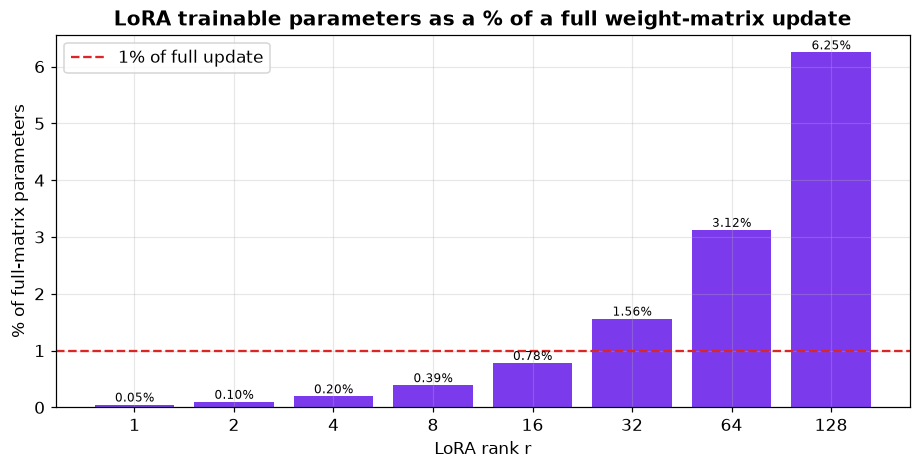

Even rank 16 trains a fraction of one percent -- yet adapts behaviour effectively.


In [29]:

# How few parameters LoRA actually trains, as rank r varies (one square weight matrix).
d_in = d_out = 4096          # a typical hidden size
full = d_out * d_in          # parameters in a full update to this matrix
ranks = [1, 2, 4, 8, 16, 32, 64, 128]
lora_params = [r * (d_in + d_out) for r in ranks]
pct = [100.0 * lp / full for lp in lora_params]

print(f"Full update to one {d_out}x{d_in} matrix: {full:,} parameters\n")
print(f"{'rank r':>7} | {'LoRA params':>14} | {'% of full':>9}")
print("-" * 38)
for r, lp, p in zip(ranks, lora_params, pct):
    print(f"{r:>7} | {lp:>14,} | {p:>8.3f}%")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar([str(r) for r in ranks], pct, color=PAL["purple"])
ax.axhline(1.0, color=PAL["red"], ls="--", label="1% of full update")
ax.set_title("LoRA trainable parameters as a % of a full weight-matrix update")
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("% of full-matrix parameters")
for i, p in enumerate(pct):
    ax.text(i, p, f"{p:.2f}%", ha="center", va="bottom", fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()
print("Even rank 16 trains a fraction of one percent -- yet adapts behaviour effectively.")


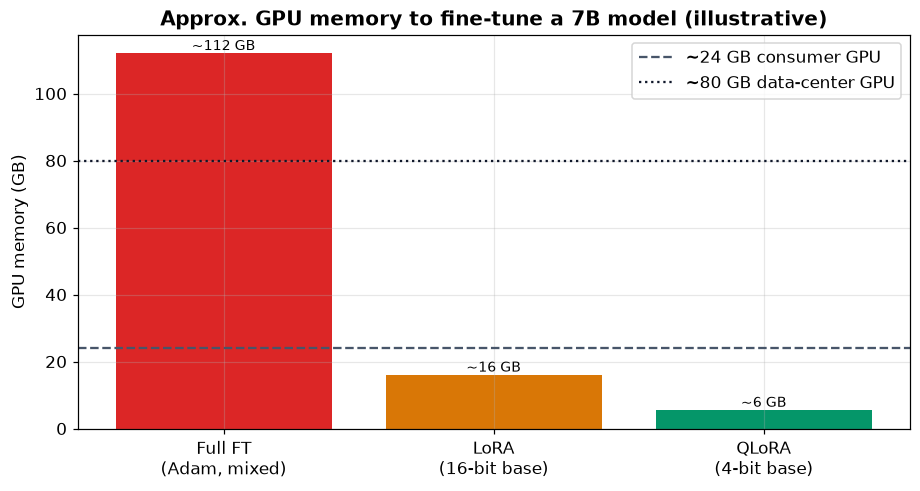

Full FT ~112 GB (needs big GPUs) | LoRA ~16 GB | QLoRA ~6 GB (fits one consumer GPU).
Numbers are rough teaching estimates; real usage depends on sequence length, batch size, and framework.


In [31]:

# Memory to FINE-TUNE a 7B model: full FT vs LoRA vs QLoRA (illustrative estimates).
params_b = 7.0  # billions
# Full FT (mixed precision, Adam): weights + grads + 2 optimizer moments + activations.
# Rule-of-thumb ~16 bytes per parameter of state for Adam mixed-precision training.
full_ft_gb  = params_b * 16
# LoRA: frozen base in 16-bit (~2 bytes/param) + small adapter training overhead.
lora_gb     = params_b * 2 + 2
# QLoRA: frozen base in 4-bit (~0.5 bytes/param) + small adapter training overhead.
qlora_gb    = params_b * 0.5 + 2

methods = ["Full FT\n(Adam, mixed)", "LoRA\n(16-bit base)", "QLoRA\n(4-bit base)"]
mem = [full_ft_gb, lora_gb, qlora_gb]
colors = [PAL["red"], PAL["amber"], PAL["green"]]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.bar(methods, mem, color=colors)
ax.axhline(24, color=PAL["slate"], ls="--", label="~24 GB consumer GPU")
ax.axhline(80, color=PAL["ink"], ls=":", label="~80 GB data-center GPU")
ax.set_title("Approx. GPU memory to fine-tune a 7B model (illustrative)")
ax.set_ylabel("GPU memory (GB)")
for b, m in zip(bars, mem):
    ax.text(b.get_x()+b.get_width()/2, m, f"~{m:.0f} GB", ha="center", va="bottom", fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()
print(f"Full FT ~{full_ft_gb:.0f} GB (needs big GPUs) | LoRA ~{lora_gb:.0f} GB | QLoRA ~{qlora_gb:.0f} GB (fits one consumer GPU).")
print("Numbers are rough teaching estimates; real usage depends on sequence length, batch size, and framework.")


### 12.3 Reference: LoRA with the PEFT library

Real training is too heavy to run here, but the code is short. With Hugging Face **`peft`** you wrap a base model and train only the adapters:

```python
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

base = AutoModelForCausalLM.from_pretrained("some-base-model")

lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],   # which layers get adapters
    task_type="CAUSAL_LM",
)
model = get_peft_model(base, lora_cfg)
model.print_trainable_parameters()   # typically <1% of all parameters

# ...then train `model` with a normal Trainer / SFTTrainer loop.
# Save just the adapter (a few MB): model.save_pretrained("my-lora-adapter")
```

For **QLoRA**, load the base model 4-bit-quantized (via `bitsandbytes`) and attach the same LoRA config on top — everything else stays the same.


## 13. Quantization

> **What it is.** **Quantization** stores model weights with fewer bits — e.g. 4-bit integers instead of 16-bit floats. Fewer bits per number means **less memory** and often **faster inference**, with a usually small quality cost.

> **Why it matters.** Quantization is what lets large models **fit on smaller GPUs and laptops** and serve more requests per dollar. It is mostly an **inference/deployment** decision (QLoRA, above, applies the same idea during training).

### 14.1 The number formats
- **FP32** (*32-bit float*): full precision, 4 bytes/param — the training default, rarely needed for serving.
- **FP16 / BF16** (*16-bit floats*): 2 bytes/param, the standard for inference. **BF16** trades precision for a wider range and is very training-friendly.
- **INT8** (*8-bit integer*): 1 byte/param, roughly half the memory of FP16, minor quality loss.
- **INT4** (*4-bit integer*): 0.5 bytes/param, big savings, more noticeable but often acceptable loss.

Approx. memory to LOAD model weights (GB) = params(billions) x bytes/param

 model |       FP32 |  FP16/BF16 |       INT8 |       INT4
----------------------------------------------------------
    7B |      28.0G |      14.0G |       7.0G |       3.5G
   13B |      52.0G |      26.0G |      13.0G |       6.5G
   70B |     280.0G |     140.0G |      70.0G |      35.0G


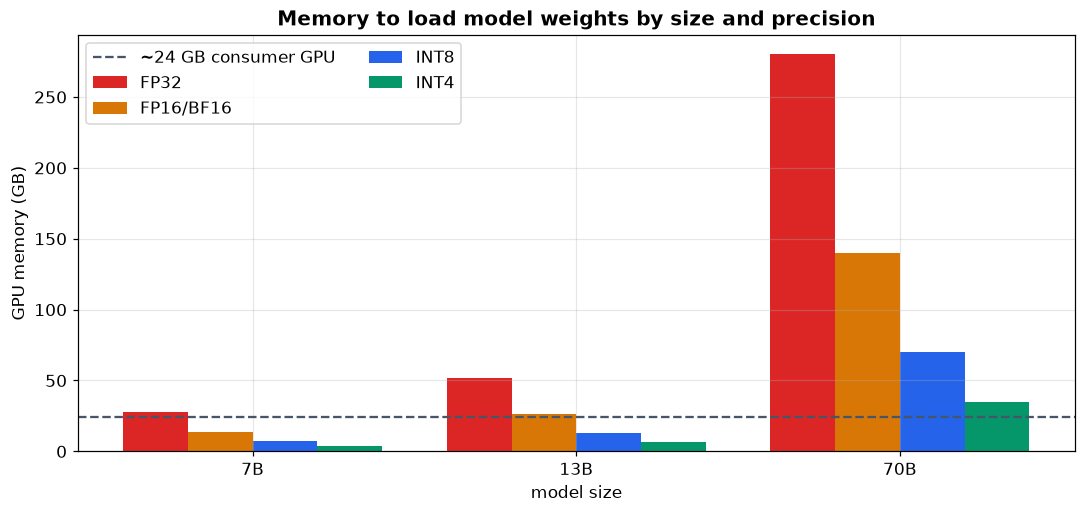

A 70B model needs ~140 GB at FP16 but ~35 GB at INT4 -- the difference between a cluster and one GPU.


In [32]:

# Memory to LOAD models at different precisions (weights only; serving, not training).
bytes_per_param = {"FP32": 4.0, "FP16/BF16": 2.0, "INT8": 1.0, "INT4": 0.5}
model_sizes_b = {"7B": 7.0, "13B": 13.0, "70B": 70.0}

print("Approx. memory to LOAD model weights (GB) = params(billions) x bytes/param\n")
header = f"{'model':>6} | " + " | ".join(f"{k:>10}" for k in bytes_per_param)
print(header); print("-" * len(header))
mem_table = {}
for name, p in model_sizes_b.items():
    row = {fmt: p * bpp for fmt, bpp in bytes_per_param.items()}
    mem_table[name] = row
    print(f"{name:>6} | " + " | ".join(f"{row[fmt]:>9.1f}G" for fmt in bytes_per_param))

x = np.arange(len(model_sizes_b)); width = 0.2
fmts = list(bytes_per_param.keys())
colors = [PAL["red"], PAL["amber"], PAL["blue"], PAL["green"]]
fig, ax = plt.subplots(figsize=(10, 4.8))
for j, fmt in enumerate(fmts):
    vals = [mem_table[n][fmt] for n in model_sizes_b]
    ax.bar(x + (j-1.5)*width, vals, width, label=fmt, color=colors[j])
ax.axhline(24, color=PAL["slate"], ls="--", label="~24 GB consumer GPU")
ax.set_xticks(x); ax.set_xticklabels(list(model_sizes_b.keys()))
ax.set_title("Memory to load model weights by size and precision")
ax.set_xlabel("model size"); ax.set_ylabel("GPU memory (GB)"); ax.legend(ncol=2)
plt.tight_layout(); plt.show()
print("A 70B model needs ~140 GB at FP16 but ~35 GB at INT4 -- the difference between a cluster and one GPU.")


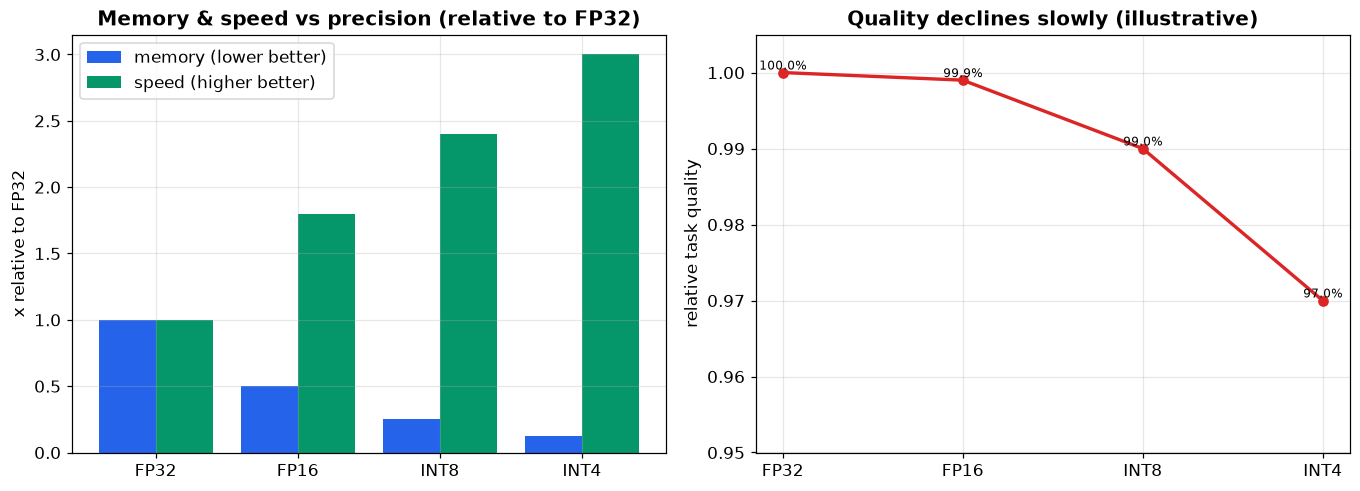

Rule of thumb: INT8 is nearly free; INT4 is the popular sweet spot for big models on small hardware.


In [33]:

# The quantization trade-off: memory + speed improve as quality slowly declines (illustrative).
formats = ["FP32", "FP16", "INT8", "INT4"]
rel_memory  = np.array([1.00, 0.50, 0.25, 0.125])   # fraction of FP32 memory
rel_speed   = np.array([1.00, 1.80, 2.40, 3.00])    # relative inference throughput
rel_quality = np.array([1.00, 0.999, 0.99, 0.97])   # relative task quality

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
xs = np.arange(len(formats))
axes[0].bar(xs - 0.2, rel_memory, 0.4, label="memory (lower better)", color=PAL["blue"])
axes[0].bar(xs + 0.2, rel_speed, 0.4, label="speed (higher better)", color=PAL["green"])
axes[0].set_xticks(xs); axes[0].set_xticklabels(formats)
axes[0].set_title("Memory & speed vs precision (relative to FP32)")
axes[0].set_ylabel("x relative to FP32"); axes[0].legend()

axes[1].plot(formats, rel_quality, "o-", color=PAL["red"], lw=2.2)
axes[1].set_ylim(0.95, 1.005)
axes[1].set_title("Quality declines slowly (illustrative)")
axes[1].set_ylabel("relative task quality")
for i, q in enumerate(rel_quality):
    axes[1].text(i, q, f"{q*100:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()
print("Rule of thumb: INT8 is nearly free; INT4 is the popular sweet spot for big models on small hardware.")


## 14. Agents

> **What it is.** An **agent** is an LLM placed inside a **loop** where it can **act on the world** — call tools, run code, query APIs, read files — observe the results, and decide what to do next, repeating until the task is done.

> **Why it matters.** A plain chatbot can only *talk*. An agent can *do*: look up live data, run a calculation, file a ticket, browse a page. This turns the model from an answer-generator into a **task-completer**.

### 14.1 Agent vs chatbot

| | Chatbot | Agent |
|---|---|---|
| Interaction | One question → one answer | Multi-step loop |
| Tools | None | Calls tools / APIs / code |
| State | Just the conversation | Tracks progress toward a goal |
| Failure handling | Re-answers | Can retry, adjust, replan |
| Good for | Q&A, drafting, chat | Multi-step tasks with real actions |

### 14.2 The core loop
Almost every agent runs the same cycle: **Think → Act → Observe → repeat → Answer**.

1. **Think** — reason about the goal and what's needed next.
2. **Act** — choose a tool and arguments.
3. **Observe** — read the tool's result.
4. Loop until confident, then **Answer**.

This is exactly the **ReAct** pattern (*Reason + Act*) from the reasoning section — now wired to real tools.


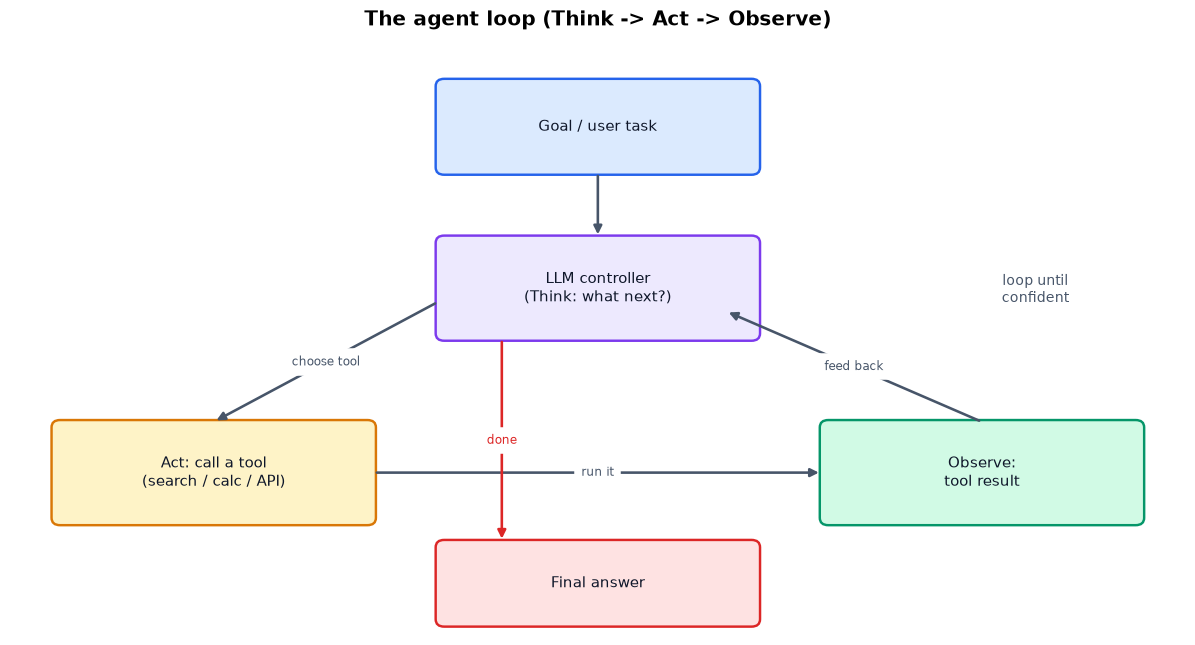

In [34]:

# Diagram of the agent loop: the model cycles through tools until it can answer.
fig, ax = blank_canvas(11, 6, xlim=11, ylim=6.5, title="The agent loop (Think -> Act -> Observe)")

add_box(ax, 4.0, 5.0, 3.0, 1.0, "Goal / user task", PAL["lblue"], PAL["blue"])
add_box(ax, 4.0, 3.2, 3.0, 1.1, "LLM controller\n(Think: what next?)", PAL["lpurple"], PAL["purple"])
add_box(ax, 0.4, 1.2, 3.0, 1.1, "Act: call a tool\n(search / calc / API)", PAL["lamber"], PAL["amber"])
add_box(ax, 7.6, 1.2, 3.0, 1.1, "Observe:\ntool result", PAL["lgreen"], PAL["green"])
add_box(ax, 4.0, 0.1, 3.0, 0.9, "Final answer", PAL["lred"], PAL["red"])

add_arrow(ax, 5.5, 5.0, 5.5, 4.3)
add_arrow(ax, 4.0, 3.6, 1.9, 2.3, text="choose tool")
add_arrow(ax, 3.4, 1.75, 7.6, 1.75, text="run it")
add_arrow(ax, 9.1, 2.3, 6.7, 3.5, text="feed back")
add_arrow(ax, 4.6, 3.2, 4.6, 1.0, text="done", color=PAL["red"])
ax.text(9.6, 3.6, "loop until\nconfident", fontsize=9, color=PAL["slate"], ha="center")
plt.tight_layout(); plt.show()


In [35]:

# A small but RUNNABLE ReAct-style agent loop with two real tools and a rule-based controller.
# (A real agent would use an LLM to pick tools; we use transparent rules so the trace is clear.)
import re as _re

def tool_calculator(expr):
    # Safe arithmetic only: digits, operators, parentheses, decimal points, spaces.
    if not _re.fullmatch(r"[0-9+\-*/(). ]+", expr):
        return "error: unsupported characters"
    try:
        return str(eval(expr, {"__builtins__": {}}, {}))
    except Exception as e:
        return f"error: {e}"

FACTS = {
    "speed of light": "299,792,458 meters per second",
    "pi": "3.14159",
    "founding year": "2014",
}
def tool_lookup(key):
    for k, v in FACTS.items():
        if k in key.lower():
            return v
    return "not found"

TOOLS = {"calculator": tool_calculator, "lookup": tool_lookup}

def controller(goal, scratchpad):
    # Decide the next (thought, action, tool, arg) given the goal and what we've observed.
    text = goal.lower()
    already = [s["tool"] for s in scratchpad]
    if any(c.isdigit() for c in goal) and _re.search(r"[+\-*/]", goal) and "calculator" not in already:
        expr = _re.sub(r"[^0-9+\-*/(). ]", "", goal)
        return ("This needs arithmetic.", "use calculator", "calculator", expr.strip())
    if "speed of light" in text and "lookup" not in already:
        return ("I should look up a fact.", "use lookup", "lookup", "speed of light")
    return ("I have enough to answer.", "finish", None, None)

def run_agent(goal, max_steps=4):
    print("GOAL:", goal)
    scratchpad = []
    for step in range(1, max_steps + 1):
        thought, action, tool, arg = controller(goal, scratchpad)
        print(f"  Step {step} | Thought: {thought}")
        if tool is None:
            answer = scratchpad[-1]["observation"] if scratchpad else "(no tool needed)"
            print(f"  Step {step} | Action: {action}")
            print(f"  ANSWER: {answer}\n")
            return answer
        obs = TOOLS[tool](arg)
        print(f"  Step {step} | Action: {action}('{arg}')  ->  Observation: {obs}")
        scratchpad.append({"tool": tool, "arg": arg, "observation": obs})
    print("  Stopped: hit step limit.\n")
    return scratchpad[-1]["observation"] if scratchpad else None

_ = run_agent("What is 1234 * 5678 + 42?")
_ = run_agent("What is the speed of light?")


GOAL: What is 1234 * 5678 + 42?
  Step 1 | Thought: This needs arithmetic.
  Step 1 | Action: use calculator('1234 * 5678 + 42')  ->  Observation: 7006694
  Step 2 | Thought: I have enough to answer.
  Step 2 | Action: finish
  ANSWER: 7006694

GOAL: What is the speed of light?
  Step 1 | Thought: I should look up a fact.
  Step 1 | Action: use lookup('speed of light')  ->  Observation: 299,792,458 meters per second
  Step 2 | Thought: I have enough to answer.
  Step 2 | Action: finish
  ANSWER: 299,792,458 meters per second



**When agents are overkill.** Loops, tool calls, and retries add **latency, cost, and failure surface**. If a single well-crafted prompt (optionally with RAG) answers the question, use that. Reach for an agent only when the task genuinely requires **multiple steps, real actions, or branching decisions** that you can't script in advance.


## 15. Agent reasoning patterns & architectures

The single agent loop is the foundation. Real systems compose it into richer patterns — pick the simplest one that fits the task.

| Pattern | Idea | Best for |
|---|---|---|
| **ReAct** | Interleave reasoning + tool calls in one loop | General tool-using tasks |
| **Plan-and-execute** | Make a full plan first, then execute steps | Multi-step tasks with clear structure |
| **Reflective (Reflexion)** | Critique your own output, then retry | Quality-sensitive tasks; reduce errors |
| **Multi-agent** | Several specialized agents collaborate | Distinct roles (researcher, coder, reviewer) |
| **Hierarchical** | A manager agent delegates to workers | Large tasks split into sub-tasks |

### 15.1 Two shapes, side by side
- **ReAct** decides the *next* action each step (flexible, can wander).
- **Plan-and-execute** commits to a plan up front (structured, but a bad plan derails everything; often paired with a *replan* step).


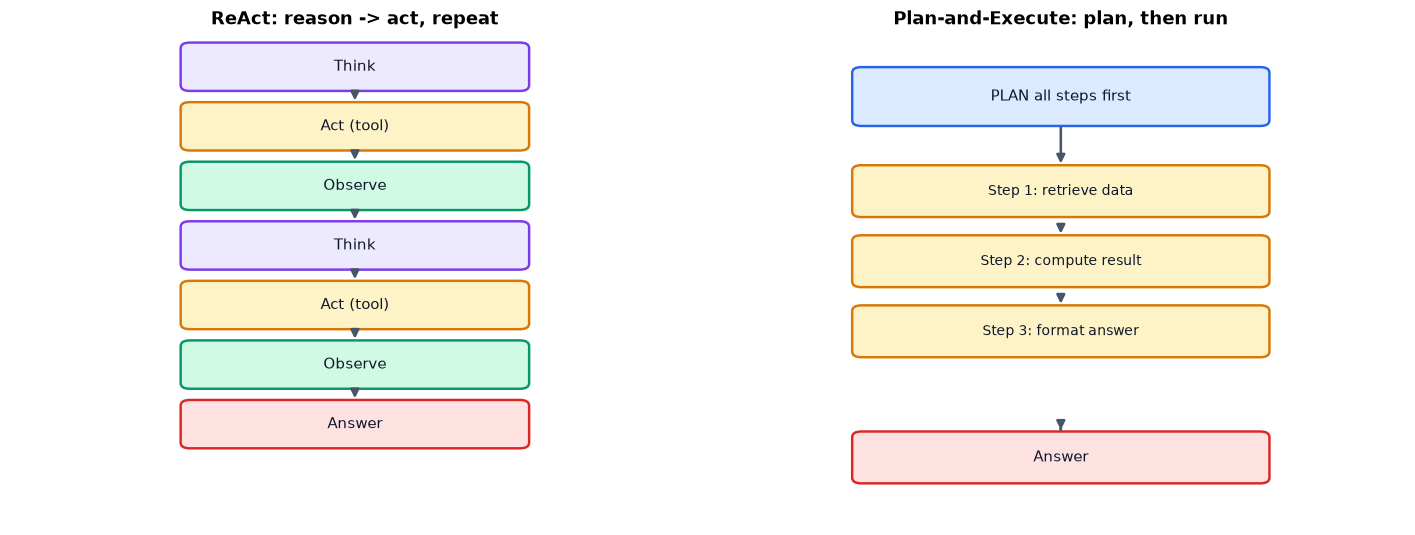

In [36]:

# Side-by-side: ReAct (decide step-by-step) vs Plan-and-Execute (plan first, then run).
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
for ax in (axL, axR):
    ax.set_xlim(0, 6); ax.set_ylim(0, 7); ax.axis("off")

axL.set_title("ReAct: reason -> act, repeat", fontsize=12, weight="bold")
react_steps = ["Think", "Act (tool)", "Observe", "Think", "Act (tool)", "Observe", "Answer"]
for i, s in enumerate(react_steps):
    y = 6.2 - i*0.85
    fc = PAL["lpurple"] if "Think" in s else PAL["lamber"] if "Act" in s else PAL["lgreen"] if "Observe" in s else PAL["lred"]
    ec = PAL["purple"] if "Think" in s else PAL["amber"] if "Act" in s else PAL["green"] if "Observe" in s else PAL["red"]
    add_box(axL, 1.5, y, 3.0, 0.65, s, fc, ec, fs=10)
    if i < len(react_steps) - 1:
        add_arrow(axL, 3.0, y, 3.0, y-0.20)

axR.set_title("Plan-and-Execute: plan, then run", fontsize=12, weight="bold")
add_box(axR, 1.2, 5.7, 3.6, 0.8, "PLAN all steps first", PAL["lblue"], PAL["blue"], fs=10)
plan = ["Step 1: retrieve data", "Step 2: compute result", "Step 3: format answer"]
for i, s in enumerate(plan):
    y = 4.4 - i*1.0
    add_box(axR, 1.2, y, 3.6, 0.7, s, PAL["lamber"], PAL["amber"], fs=9)
    add_arrow(axR, 3.0, y+0.9 if i else 5.7, 3.0, y+0.7)
add_box(axR, 1.2, 0.6, 3.6, 0.7, "Answer", PAL["lred"], PAL["red"], fs=10)
add_arrow(axR, 3.0, 1.4, 3.0, 1.3)
plt.tight_layout(); plt.show()


## 16. Frameworks

> **Why they exist.** You *can* build agents and RAG with plain API calls (as this notebook does). Frameworks provide reusable plumbing — prompt templates, memory, tool wrappers, retrievers, orchestration, tracing — so you write less glue code.

> **The trade-off.** They speed up prototyping but add abstraction and version churn. For simple apps, plain calls are often clearer; reach for a framework when **orchestration complexity** grows.

| Framework | What it is | Strengths | Watch out for | Best for |
|---|---|---|---|---|
| **LangChain** | Broad LLM-app toolkit | Huge ecosystem, many integrations | Abstraction-heavy, fast-changing | General apps, gluing components |
| **LangGraph** | Graph-based agent orchestration | Explicit state machine, cycles, control | More setup | Complex, stateful, multi-step agents |
| **LlamaIndex** | Data framework for RAG | Excellent ingestion / indexing / retrieval | Less of a general agent tool | Document-heavy RAG |
| **Haystack** | Production NLP/LLM pipelines | Modular, search-oriented, mature | Smaller agent focus | Search + RAG pipelines |
| **CrewAI** | Role-based multi-agent | Simple "crew of agents" mental model | Young, opinionated | Multi-agent collaboration |
| **AutoGen** | Multi-agent conversations | Strong agent-to-agent messaging | Complexity at scale | Research, multi-agent systems |
| **OpenAI Agents SDK** | Lightweight agent loop + tools | Minimal, official, clean | Tied to one provider | Provider-native agents |
| **Semantic Kernel** | Microsoft orchestration SDK | C#/Python, enterprise, planners | Heavier concepts | .NET / enterprise stacks |
| **PydanticAI** | Type-safe agent framework | Structured, validated outputs | Newer ecosystem | Production, typed I/O |
| **SmolAgents** | Minimal code-writing agents | Tiny, transparent, "agents write code" | Bare-bones | Learning, small agents |
| **DSPy** | Programming (not prompting) LLMs | **Optimizes** prompts/weights automatically | Different mental model | Systematic prompt optimization |

### 16.1 Which to choose
- **Document Q&A / RAG?** → **LlamaIndex** (or **Haystack**).
- **Complex stateful agents?** → **LangGraph**.
- **Multi-agent teams?** → **CrewAI** or **AutoGen**.
- **Type-safe production outputs?** → **PydanticAI**.
- **Stop hand-tuning prompts?** → **DSPy**.
- **Just learning / staying simple?** → plain API calls or **SmolAgents**.

**Rule of thumb:** start with the smallest tool that works; adopt a framework when orchestration — not features — is your bottleneck.


## 17. Memory

> **What it is.** **Memory** is how an app carries information *across turns* (and across sessions). LLMs are **stateless** — each call only knows what's in the prompt — so memory is something **you** build around the model.

> **Why it matters.** Without it, the assistant forgets your name two messages later. With it, conversations stay coherent and personalized — but naive memory blows the context budget and cost.

### 17.1 Types of memory

| Type | How it works | Trade-off |
|---|---|---|
| **Buffer (short-term)** | Keep the last N messages verbatim | Simple; grows until it overflows context |
| **Summary** | Periodically compress old turns into a summary | Compact; loses fine detail |
| **Vector (retrieval)** | Embed past messages, retrieve relevant ones | Scales to long history; needs a store |
| **Long-term (profile)** | Persist durable facts (name, preferences) across sessions | Powerful; needs storage + privacy care |

### 17.2 Memory vs RAG
They use the same retrieval machinery but answer different questions: **memory** recalls *the conversation* ("what did **we** say?"); **RAG** recalls *your knowledge base* ("what do **the docs** say?"). Many assistants use both at once.

**When memory hurts:** stuffing the whole history into every prompt wastes tokens and can *confuse* the model with stale or irrelevant context. Summarize or retrieve instead of hoarding — and never persist sensitive data without a reason and a retention policy.


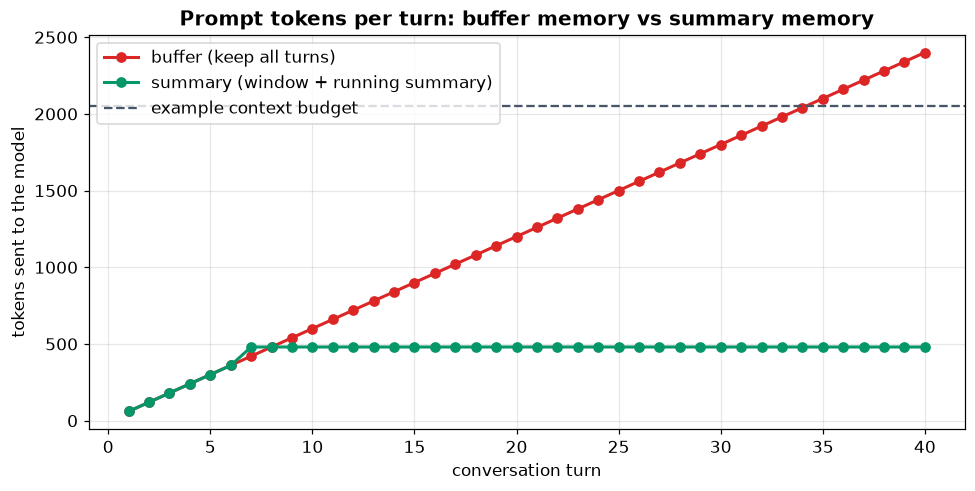

Buffer memory grows without bound (cost + eventual overflow); summary memory stays roughly flat.


In [37]:

# Buffer vs summary memory: how the prompt's token cost grows over a long conversation.
turn_tokens = 60                      # average tokens per message
turns = np.arange(1, 41)

buffer_tokens = turns * turn_tokens   # keep everything: linear growth, unbounded
# Summary memory: keep last 6 turns verbatim + a small fixed-size running summary.
window = 6; summary_cap = 120
summary_tokens = np.minimum(turns, window) * turn_tokens + np.minimum(turns, window*3) * 0 + summary_cap
summary_tokens = np.where(turns > window, window*turn_tokens + summary_cap, turns*turn_tokens)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(turns, buffer_tokens, "o-", color=PAL["red"], lw=2, label="buffer (keep all turns)")
ax.plot(turns, summary_tokens, "o-", color=PAL["green"], lw=2, label="summary (window + running summary)")
ax.axhline(2048, color=PAL["slate"], ls="--", label="example context budget")
ax.set_title("Prompt tokens per turn: buffer memory vs summary memory")
ax.set_xlabel("conversation turn"); ax.set_ylabel("tokens sent to the model")
ax.legend()
plt.tight_layout(); plt.show()
print("Buffer memory grows without bound (cost + eventual overflow); summary memory stays roughly flat.")


## 18. Evaluation

> **What it is.** **Evaluation** is how you measure whether an LLM system is actually good — and whether a change made it better or worse. Because outputs are open-ended, you can't rely on a single accuracy number.

> **Why it matters.** "It looked fine in a demo" is not a quality bar. Without evaluation you can't catch regressions, compare prompts/models, or trust the system in production. **If you can't measure it, you can't improve it.**

### 18.1 What to measure

| Dimension | Question | How |
|---|---|---|
| **Accuracy / correctness** | Is the answer right? | Exact match, F1, task metric |
| **Relevance** | Does it address the question? | Embedding similarity, judge |
| **Hallucination** | Did it invent unsupported facts? | Inverse of groundedness |
| **Latency** | Fast enough? | Measure wall-clock time |
| **Cost** | Affordable per request? | Token accounting |
| **Safety** | Refuses harmful requests, no PII leak? | Red-team tests, filters |


In [38]:

# Reference-based scoring: exact match and token-level F1 against gold answers.
def normalize(s):
    return _re.sub(r"[^a-z0-9 ]", "", s.lower()).split()

def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))

def token_f1(pred, gold):
    p, g = normalize(pred), normalize(gold)
    if not p or not g:
        return 0.0
    common = 0
    g_count = {}
    for w in g:
        g_count[w] = g_count.get(w, 0) + 1
    for w in p:
        if g_count.get(w, 0) > 0:
            common += 1; g_count[w] -= 1
    if common == 0:
        return 0.0
    precision = common / len(p); recall = common / len(g)
    return 2 * precision * recall / (precision + recall)

cases = [
    ("The capital of France is Paris.", "Paris", "exact-ish"),
    ("Paris", "Paris", "perfect"),
    ("It is probably London.", "Paris", "wrong"),
    ("The refund window is 30 days.", "30 days", "partial overlap"),
]
print(f"{'prediction':<35}{'gold':<12}{'EM':>4}{'F1':>7}")
print("-" * 60)
for pred, gold, _tag in cases:
    print(f"{pred:<35}{gold:<12}{exact_match(pred,gold):>4}{token_f1(pred,gold):>7.2f}")
print("\nExact match is strict; F1 gives partial credit for word overlap.")


prediction                         gold          EM     F1
------------------------------------------------------------
The capital of France is Paris.    Paris          0   0.29
Paris                              Paris          1   1.00
It is probably London.             Paris          0   0.00
The refund window is 30 days.      30 days        0   0.50

Exact match is strict; F1 gives partial credit for word overlap.


### 18.3 Common failure modes to test for

| Failure | Symptom | Catch it with |
|---|---|---|
| Hallucination | Confident but unsupported claims | Groundedness check |
| Outdated answer | Correct last year, wrong now | RAG + freshness tests |
| Format drift | Breaks expected JSON/schema | Schema validation in tests |

## 19. Safety and security

> **What it is.** LLM apps face new risks: untrusted text can carry **instructions**, models can **leak** data or be **tricked**, and giving a model **tools** means a bad decision can take a real action.

> **Why it matters.** A vulnerable LLM feature can leak secrets, run unintended actions, or produce harmful output. Treat **all model input as untrusted** and **all model output as unverified** until checked.

### 19.1 The main threats
- **Prompt injection:** malicious instructions hidden in retrieved/web/user content ("ignore previous instructions and..."). The #1 LLM-specific risk, especially with RAG and agents.
- **Jailbreaks:** crafted prompts that try to bypass safety rules.
- **Data leakage / PII:** the model echoes secrets or **PII** (*Personally Identifiable Information*) from context or training.
- **Insecure tool use:** an agent runs a dangerous action (delete data, send money) on a bad decision.

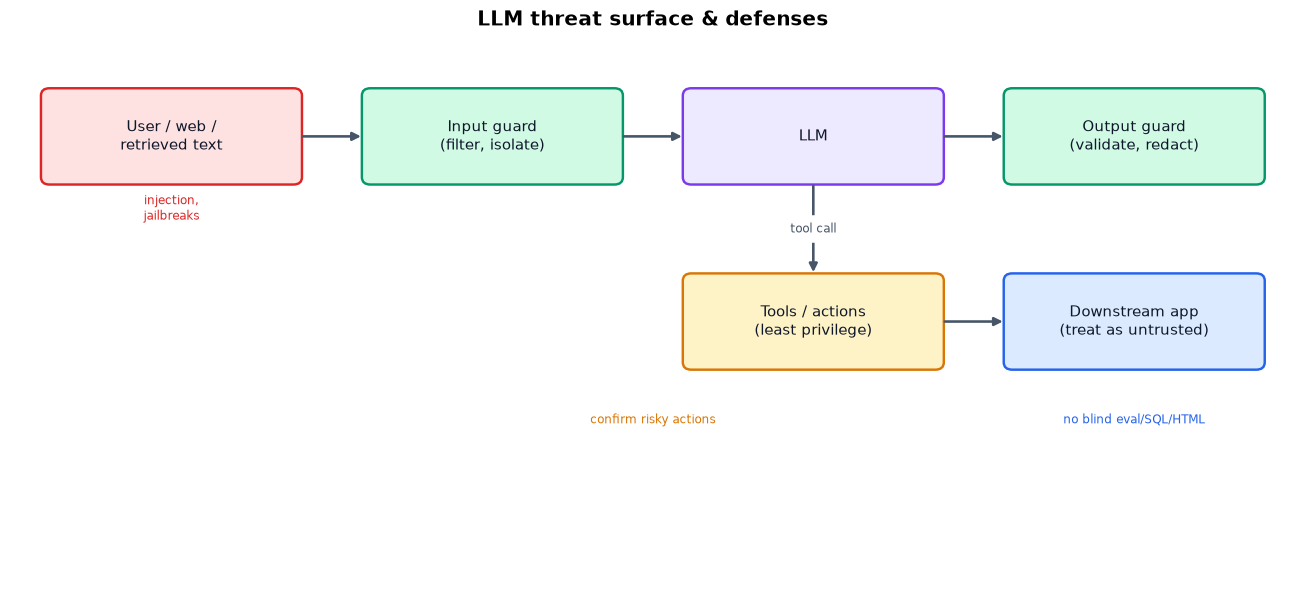

In [39]:

# Threat diagram: where risks enter an LLM system and where to place defenses.
fig, ax = blank_canvas(12, 5.6, xlim=12, ylim=6, title="LLM threat surface & defenses")

add_box(ax, 0.3, 4.4, 2.4, 1.0, "User / web /\nretrieved text", PAL["lred"], PAL["red"])
add_box(ax, 3.3, 4.4, 2.4, 1.0, "Input guard\n(filter, isolate)", PAL["lgreen"], PAL["green"])
add_box(ax, 6.3, 4.4, 2.4, 1.0, "LLM", PAL["lpurple"], PAL["purple"])
add_box(ax, 9.3, 4.4, 2.4, 1.0, "Output guard\n(validate, redact)", PAL["lgreen"], PAL["green"])
add_arrow(ax, 2.7, 4.9, 3.3, 4.9)
add_arrow(ax, 5.7, 4.9, 6.3, 4.9)
add_arrow(ax, 8.7, 4.9, 9.3, 4.9)

add_box(ax, 6.3, 2.4, 2.4, 1.0, "Tools / actions\n(least privilege)", PAL["lamber"], PAL["amber"])
add_box(ax, 9.3, 2.4, 2.4, 1.0, "Downstream app\n(treat as untrusted)", PAL["lblue"], PAL["blue"])
add_arrow(ax, 7.5, 4.4, 7.5, 3.4, text="tool call")
add_arrow(ax, 8.7, 2.9, 9.3, 2.9)

ax.text(1.5, 4.0, "injection,\njailbreaks", fontsize=8, color=PAL["red"], ha="center")
ax.text(6, 1.8, "confirm risky actions", fontsize=8, color=PAL["amber"], ha="center")
ax.text(10.5, 1.8, "no blind eval/SQL/HTML", fontsize=8, color=PAL["blue"], ha="center")
plt.tight_layout(); plt.show()


## 20. Production concerns

> **What it is.** Moving from a notebook demo to a reliable, affordable service: handling failures, controlling cost and latency, and being able to **see** what's happening.

> **Why it matters.** Production traffic is messy — APIs fail, costs spike, latency varies. The patterns below are what keep an LLM feature **fast, cheap, and observable**.

### 20.1 The toolkit

| Concern | Pattern |
|---|---|
| **Latency (perceived)** | **Streaming** tokens as they generate |
| **Cost** | **Caching**, prompt trimming, **model routing** (small model first) |
| **Reliability** | **Retries** with backoff, **fallback** model, timeouts |
| **Throughput** | **Batching** requests |
| **Visibility** | **Logging, tracing, monitoring** (latency, cost, error rate per call) |
| **Quality control** | Output validation + the eval/regression tests from §18 |
